In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, wilcoxon
import plotly.express as px
import plotly.graph_objects as go
import nbformat

from scipy.stats import ttest_ind, f_oneway
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib_venn import venn2
import os
import scipy.cluster.hierarchy as sch

In [11]:
target_CAF=["FAP","PDGFRA","PDGFRB","S100A4","LRRC15","IL1R1","IL1R2","SMO"]


cafs_factors_receptors=  ["TGFB1","TGFB2","TGFB3", "TGFBR1","TGFBR2","TGFBR3","IL6", "IL6R", "IL10RA","IL10RB", "CXCL8", "CXCL12", 
 "CCR5", "CXCR2", "CXCR1", "CXCR4", "CXCL10","CXCL9","HGF", "MET", "FGF1","FGF2","FGF7","FGF10", "FGFR1","FGFR2","FGFR3","FGFR4","IL11","HAS1","HAS2","HYAL1","HYAL2"]




genes_of_interest = ['FGFR2', 'IL6R', 'CCR5', 'HGF', 'IL10RB',
       'TGFB1', 'TGFBR2', 'CCR2', 'MET', 'LRRC15', 'IL1R1', 'CXCR2', 'IL10RA',
       'CXCL10', 'FGF2', 'FGF7', 'FGFR4', 'IL6ST', 'CXCL9', 'PDGFRB', 'S100A4',
       'TGFB2', 'TGFB3', 'TGFBR3', 'CXCR4', 'FAP', 'TGFBR1', 'PDGFRA', 'FGFR1',
       'FGFR3', 'FGF1', 'IL1R2', 'CXCL12', 'CXCL8', 'IL6', 'CXCR1', 'FGF10']

In [12]:
fibr_gene_expression_modified=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged_new/fibroblasts_gene_expression_data_new_batch_merged_with_metadata.csv")
geomx_metadata_modified = pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/batch_merged_geomx_metadata.csv")     


In [ ]:
"""
fibroblasts_gene_expression_T_reset = fibroblasts_gene_expression_T.reset_index()

# Optionally, rename the new column (if you didn't already rename the index)
fibroblasts_gene_expression_T_reset.rename(columns={'index': 'dcc_filename'}, inplace=True)

fibroblasts_gene_expression_T_reset.iloc[0, 0]='dcc_filename'
# Now 'dcc_filename' is a regular column, not the index

fibroblasts_gene_expression_T_reset.columns = fibroblasts_gene_expression_T_reset.iloc[0]


# Drop the first row
fibroblasts_gene_expression_T_reset = fibroblasts_gene_expression_T_reset.drop(index=fibroblasts_gene_expression_T_reset.index[0])
len(fibroblasts_gene_expression_T_reset)

"""

423

In [ ]:
""""
clinical_subset = geomx_metadata_modified[["dcc_filename","Sample", "PFS_quartile", "OS_quartile", "BRCA_status", "HRP_status","Segment"]]
#clinical_subset['dcc_filename'] = clinical_subset['dcc_filename'].str.replace('-', '.', regex=False)

#clinical_subset = clinical_subset.drop_duplicates(subset="Sample")
# Merge on the 'Sample' column
#merged_df = pd.merge(geomx_metadata, clinical_subset, on="Sample", how="left")

# Save the result
#merged_df.to_csv("geomx_with_clinical.csv", index=False)
#clinical_subset
fibr_gene_expression_modified = pd.merge(fibroblasts_gene_expression_T_reset, clinical_subset, on="dcc_filename", how="left")
fibr_gene_expression_modified.to_csv("/Users/nikamikhailava/Desktop/batch_merged/filtered_fibroblasts_gene_exp_transposed_w_clinical.csv", index=False)
fibr_gene_expression_modified.head(5)

"""


,dcc_filename,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,...,MAPK8IP2,ARSA,ACR,RABL2B,Sample,PFS_quartile,OS_quartile,BRCA_status,HRP_status,Segment
0,DSP-1001660016604-A-A02.dcc,1.718431,2.137428,1.836881,1.997698,0.161226,2.480789,4.36481,2.270061,0.033787,...,2.097976,1.991563,-0.115321,2.171023,S130_iOme,1,1,0.0,1.0,stroma
1,DSP-1001660016604-A-A04.dcc,1.6221,2.027326,1.737519,1.901971,0.158211,2.375319,5.534481,2.16377,0.033655,...,2.000658,2.63368,-0.11439,2.073686,S130_iOme,1,1,0.0,1.0,stroma
2,DSP-1001660016604-A-A05.dcc,1.427961,1.505719,1.830641,1.348903,0.165076,2.201253,5.497989,2.271254,0.033957,...,1.45118,2.419147,1.253395,1.018083,S130_iOme,1,1,0.0,1.0,tumor
3,DSP-1001660016604-A-A07.dcc,1.353614,1.787912,1.868598,1.631783,0.164922,2.126467,6.245903,2.308907,0.03395,...,1.166335,2.975583,1.474534,1.23925,S130_iOme,1,1,0.0,1.0,tumor
4,DSP-1001660016604-A-A08.dcc,1.829375,1.602863,1.291572,1.448092,0.164608,1.941802,3.83659,1.731314,0.033936,...,1.550127,2.550633,1.858295,1.623058,S130_iOme,1,1,0.0,1.0,stroma


In [13]:

fibroblast_expr_matrix = fibr_gene_expression_modified.loc[:,target_CAF]
fibroblast_expr_matrix


,FAP,PDGFRA,PDGFRB,S100A4,LRRC15,IL1R1,IL1R2,SMO
0,4.172055,3.992105,4.233570,2.178173,4.517882,4.449177,1.713558,1.536280
1,4.400312,3.923597,4.220201,1.379349,4.314672,4.413359,1.286769,1.400660
2,4.261009,3.746747,3.777339,1.999248,3.990164,3.968869,-0.708671,1.364652
3,4.170900,3.561377,3.574504,1.436094,4.508047,4.700273,0.967818,1.173022
4,4.150388,4.009290,4.211563,1.671974,4.147794,3.255661,1.203948,1.026027
...,...,...,...,...,...,...,...,...
439,4.273769,4.746356,5.058931,1.955128,3.477425,3.634557,-0.325978,1.172521
440,3.781148,3.463000,3.944059,2.013649,3.769554,3.123151,0.395461,0.975807
441,3.648539,3.684119,2.906209,2.066344,3.842532,3.858804,-0.185183,-0.283512
442,3.669842,4.052819,3.058176,1.958296,3.740445,2.985763,0.758131,0.646433


In [14]:
fibr_gene_expression_modified['Sample'].unique()

array(['S130_iOme', nan, 'S131_iOme', 'S268_iOme', 'S083_iOme2',
       'S100_iOme', 'S121_iOme', 'S053_post', 'S076_post', 'S032_pre',
       'S073_post', 'S065_post', 'S084_pre', 'S057_post', 'S072_post',
       'S015_post', 'S015_pre', 'S027_post', 'S027_pre', 'S032_post',
       'S084_post', 'S098_iOme', 'S107_iOme', 'S197_iOme', 'S333_iOvaR',
       'S069_iAdnL', 'S069_pOme', 'S333_pOme'], dtype=object)

In [16]:
pre_list=['S032_pre', 'S084_pre', 'S015_pre', 'S027_pre', 'S069_pOme', 'S333_pOme']
post_list=['S130_iOme', 'S131_iOme', 'S268_iOme', 'S083_iOme2', 'S100_iOme', 'S121_iOme',
 'S053_post', 'S076_post', 'S073_post', 'S065_post', 'S057_post', 'S072_post',
 'S015_post', 'S027_post', 'S032_post', 'S084_post', 'S098_iOme', 'S107_iOme',
 'S197_iOme', 'S333_iOvaR', 'S069_iAdnL']


In [17]:
fibr_expression_pre_treatment=fibr_gene_expression_modified[fibr_gene_expression_modified['Sample'].isin(pre_list)]
fibr_expression_post_treatment=fibr_gene_expression_modified[fibr_gene_expression_modified['Sample'].isin(post_list)]

In [18]:
stroma_fibr_expr_matrix_pre=fibr_expression_pre_treatment.loc[fibr_expression_pre_treatment["Segment"]=="stroma"]
stroma_fibr_expr_matrix_pre=stroma_fibr_expr_matrix_pre.loc[:,target_CAF]
# Ensure all values are floats (if they're not already)
stroma_fibr_expr_matrix_pre = stroma_fibr_expr_matrix_pre.values
stroma_fibr_expr_matrix_pre=np.array(stroma_fibr_expr_matrix_pre)
stroma_fibr_expr_matrix_pre= stroma_fibr_expr_matrix_pre.astype(float)

stroma_fibr_expr_matrix_post=fibr_expression_post_treatment.loc[fibr_expression_post_treatment["Segment"]=="stroma"]
stroma_fibr_expr_matrix_post=stroma_fibr_expr_matrix_post.loc[:,target_CAF]
# Ensure all values are floats (if they're not already)
stroma_fibr_expr_matrix_post = stroma_fibr_expr_matrix_post.values
stroma_fibr_expr_matrix_post=np.array(stroma_fibr_expr_matrix_post)
stroma_fibr_expr_matrix_post= stroma_fibr_expr_matrix_post.astype(float)

In [19]:

stroma_sample_dist_pre = sch.distance.pdist(stroma_fibr_expr_matrix_pre,metric='euclidean')
stroma_gene_dist_pre = sch.distance.pdist(stroma_fibr_expr_matrix_pre.T, metric='euclidean')

stroma_sample_linkage_pre = sch.linkage(stroma_sample_dist_pre, method='ward')
stroma_gene_linkage_pre = sch.linkage(stroma_gene_dist_pre, method='ward')

stroma_sample_dist_post = sch.distance.pdist(stroma_fibr_expr_matrix_pre,metric='euclidean')
stroma_gene_dist_post = sch.distance.pdist(stroma_fibr_expr_matrix_pre.T, metric='euclidean')

stroma_sample_linkage_post = sch.linkage(stroma_sample_dist_post, method='ward')
stroma_gene_linkage_post = sch.linkage(stroma_gene_dist_post, method='ward')

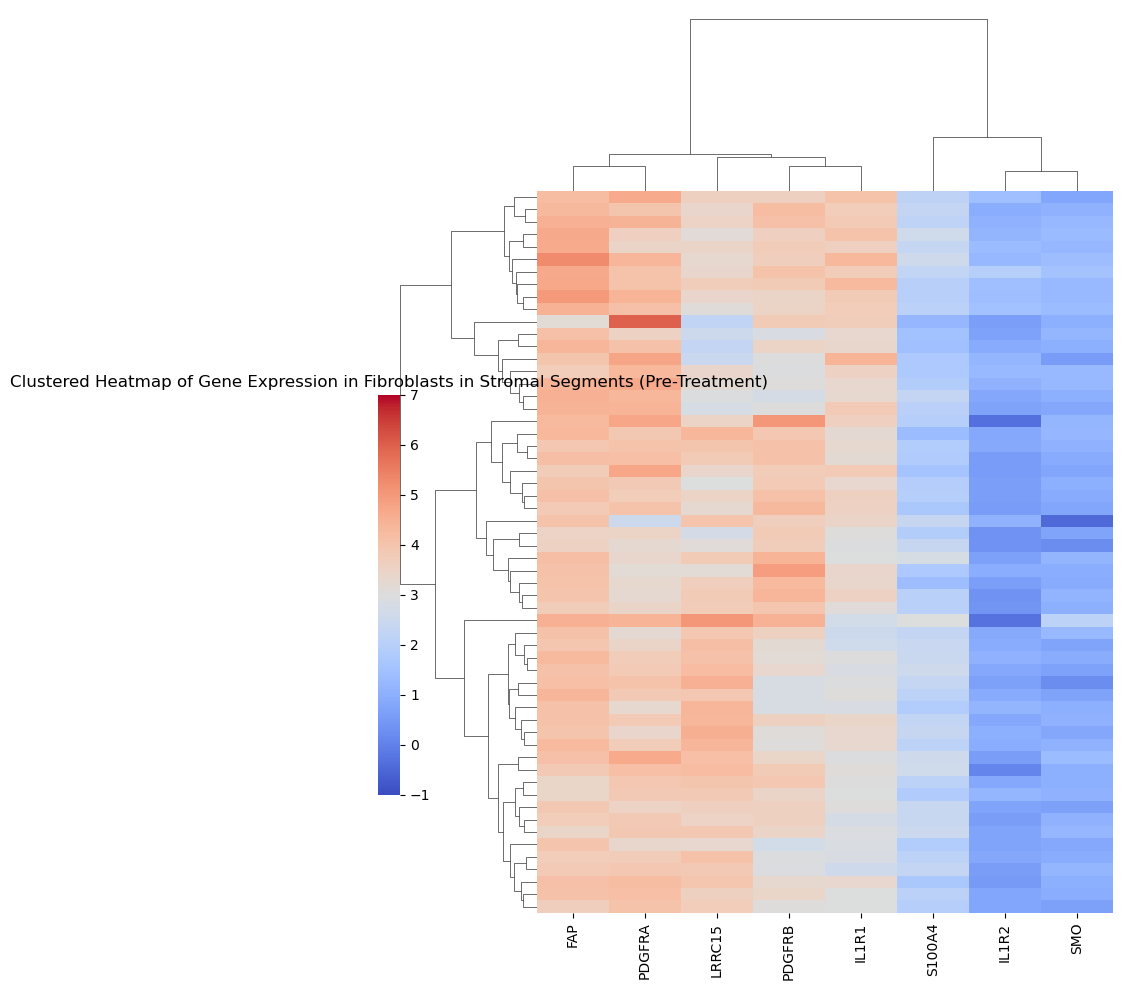

In [20]:
sns.clustermap(
    stroma_fibr_expr_matrix_pre,  # The expression matrix (samples as rows, genes as columns)
    row_linkage=stroma_sample_linkage_pre, 
    col_linkage=stroma_gene_linkage_pre,  # Clustering of samples,  # Clustering of genes
    cmap='coolwarm',  # Color map for heatmap
    figsize=(7.5, 10),  # Size of the plot
    xticklabels=target_CAF,  # Show gene names as labels on the x-axis
    yticklabels=False,  # Show sample names as labels on the y-axis
    cbar_pos=(0, .2, .03, .4),  # Color bar position adjustments
    vmin=-1,
    vmax=7  # Set to True if you want to annotate each cell with the actual expression value
)

# Display the heatmap
plt.title("Clustered Heatmap of Gene Expression in Fibroblasts in Stromal Segments (Pre-Treatment)")
plt.show()

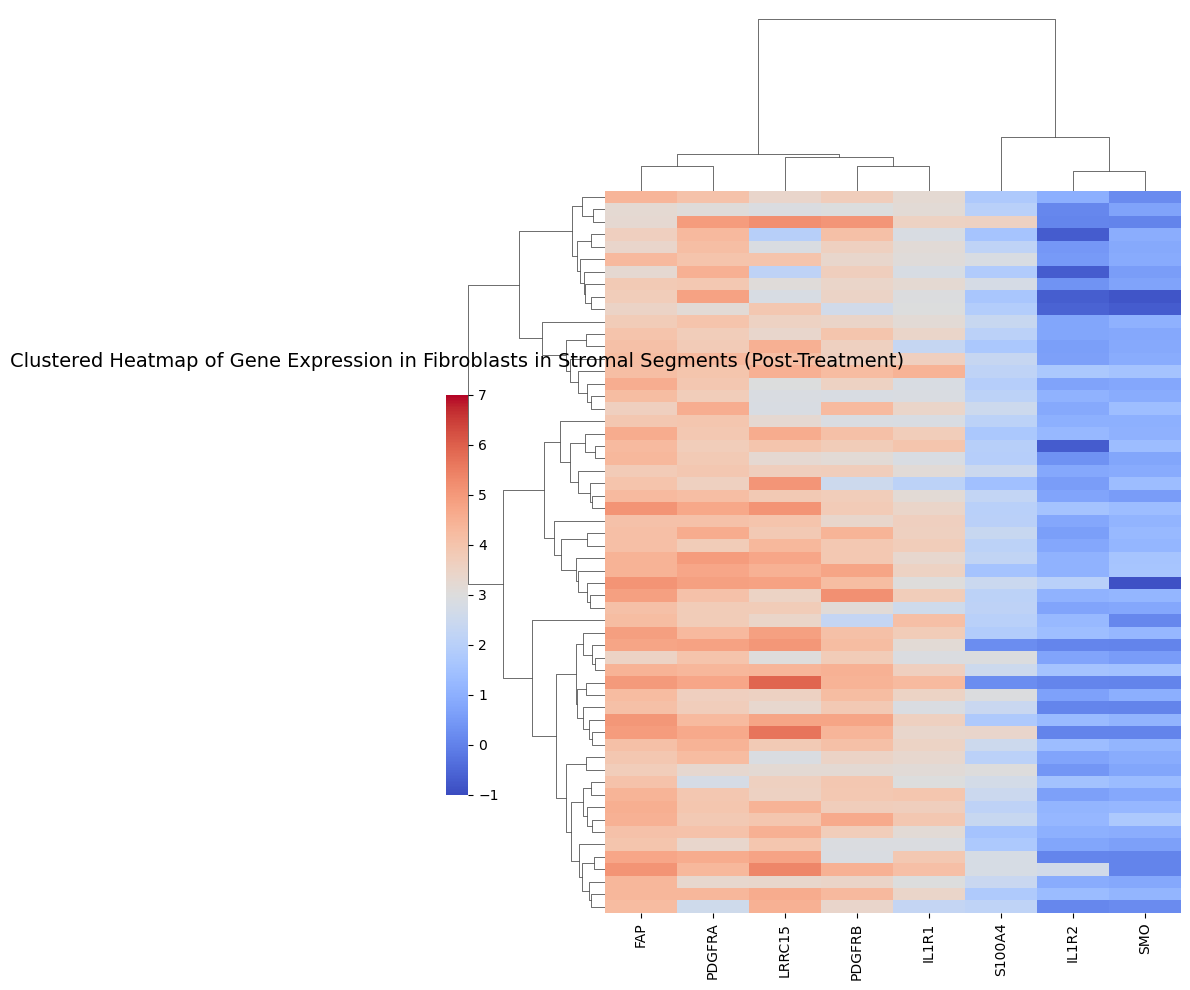

In [21]:
sns.clustermap(
    stroma_fibr_expr_matrix_post,  # The expression matrix (samples as rows, genes as columns)
    row_linkage=stroma_sample_linkage_post, 
    col_linkage=stroma_gene_linkage_post,  # Clustering of samples,  # Clustering of genes
    cmap='coolwarm',  # Color map for heatmap
    figsize=(7.5, 10),  # Size of the plot
    xticklabels=target_CAF,  # Show gene names as labels on the x-axis
    yticklabels=False,  # Show sample names as labels on the y-axis
    cbar_pos=(0, .2, .03, .4),  # Color bar position adjustments
    vmin=-1,
    vmax=7  # Set to True if you want to annotate each cell with the actual expression value
)

# Display the heatmap
plt.title("Clustered Heatmap of Gene Expression in Fibroblasts in Stromal Segments (Post-Treatment)",fontsize=14, loc='center', pad=20)
plt.show()

In [22]:
stroma_fibr_expr_matrix=fibr_gene_expression_modified.loc[fibr_gene_expression_modified["Segment"]=="stroma"]
stroma_fibr_expr_matrix=stroma_fibr_expr_matrix.loc[:,target_CAF]
# Ensure all values are floats (if they're not already)
stroma_fibr_expr_matrix = stroma_fibr_expr_matrix.values
stroma_fibr_expr_matrix=np.array(stroma_fibr_expr_matrix)
stroma_fibr_expr_matrix= stroma_fibr_expr_matrix.astype(float)

In [23]:
# Compute the distance matrix for genes and samples
stroma_sample_dist = sch.distance.pdist(stroma_fibr_expr_matrix,metric='euclidean')
stroma_gene_dist = sch.distance.pdist(stroma_fibr_expr_matrix.T, metric='euclidean')

# Perform hierarchical clustering (using complete linkage)
stroma_sample_linkage = sch.linkage(stroma_sample_dist, method='ward')
stroma_gene_linkage = sch.linkage(stroma_gene_dist, method='ward')

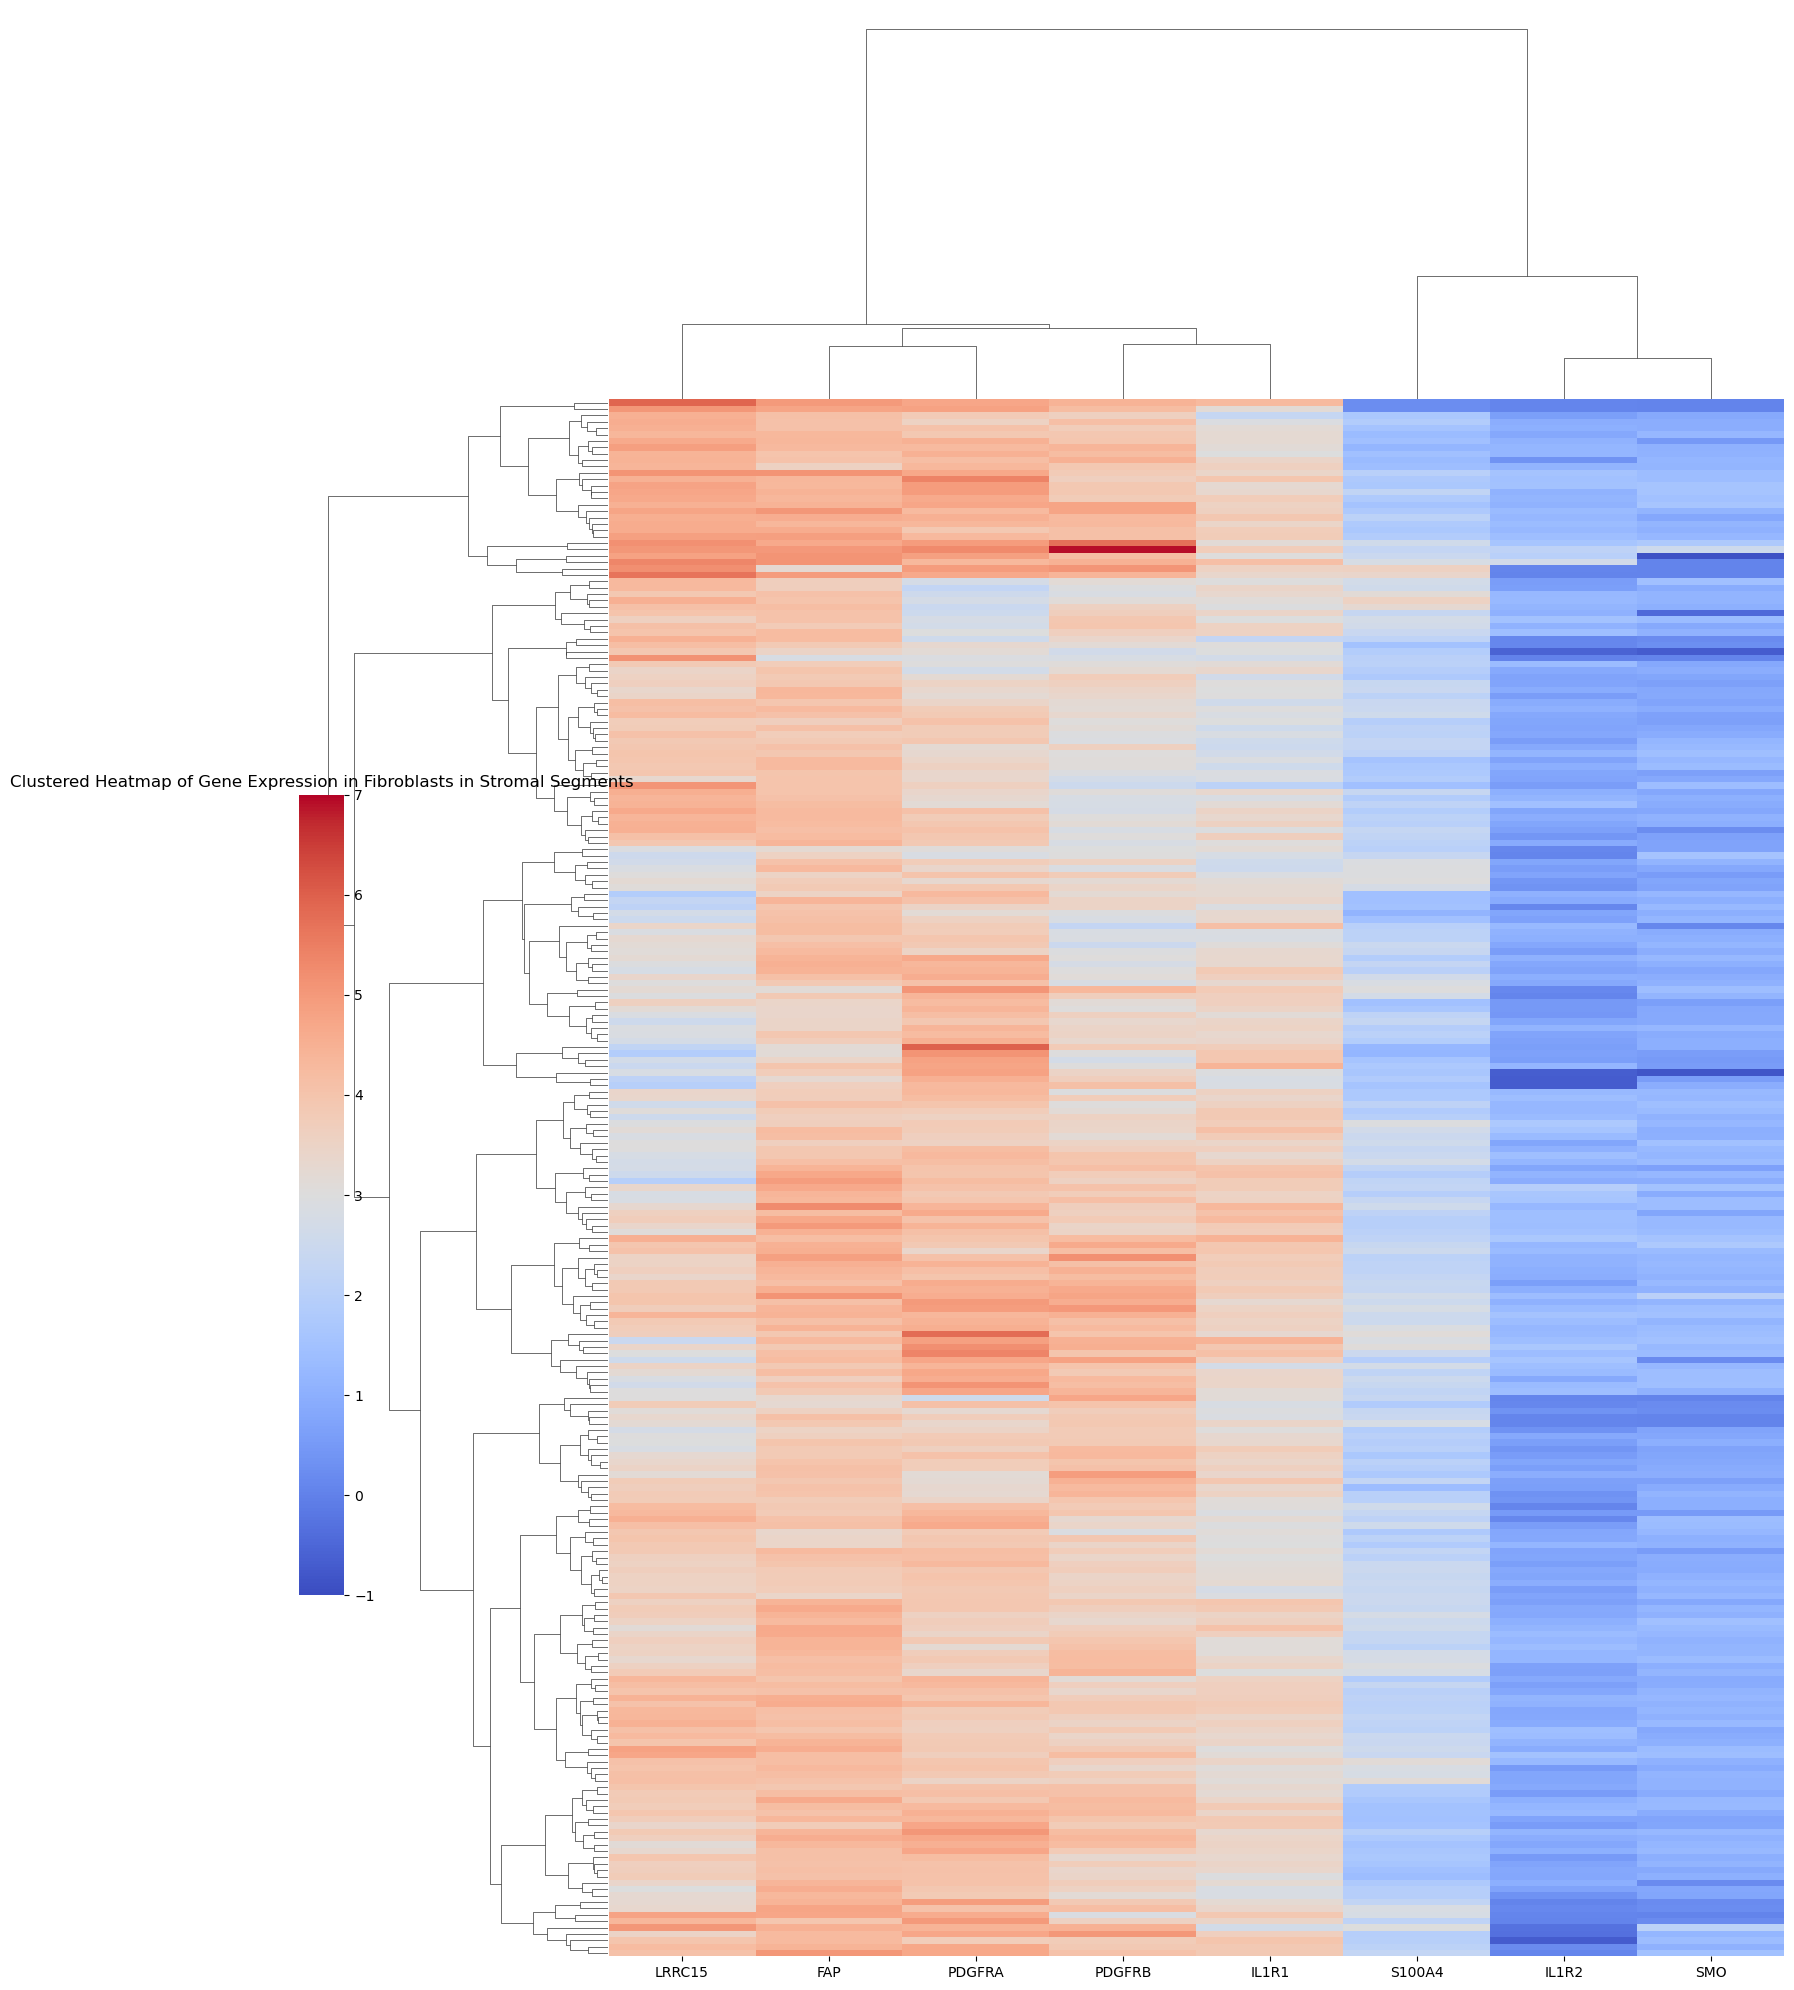

In [24]:
sns.clustermap(
    stroma_fibr_expr_matrix,  # The expression matrix (samples as rows, genes as columns)
    row_linkage=stroma_sample_linkage, 
    col_linkage=stroma_gene_linkage,  # Clustering of samples,  # Clustering of genes
    cmap='coolwarm',  # Color map for heatmap
    figsize=(15, 20),  # Size of the plot
    xticklabels=target_CAF,  # Show gene names as labels on the x-axis
    yticklabels=False,  # Show sample names as labels on the y-axis
    cbar_pos=(0, .2, .03, .4),  # Color bar position adjustments
    vmin=-1,
    vmax=7  # Set to True if you want to annotate each cell with the actual expression value
)

# Display the heatmap
plt.title("Clustered Heatmap of Gene Expression in Fibroblasts in Stromal Segments")
plt.show()

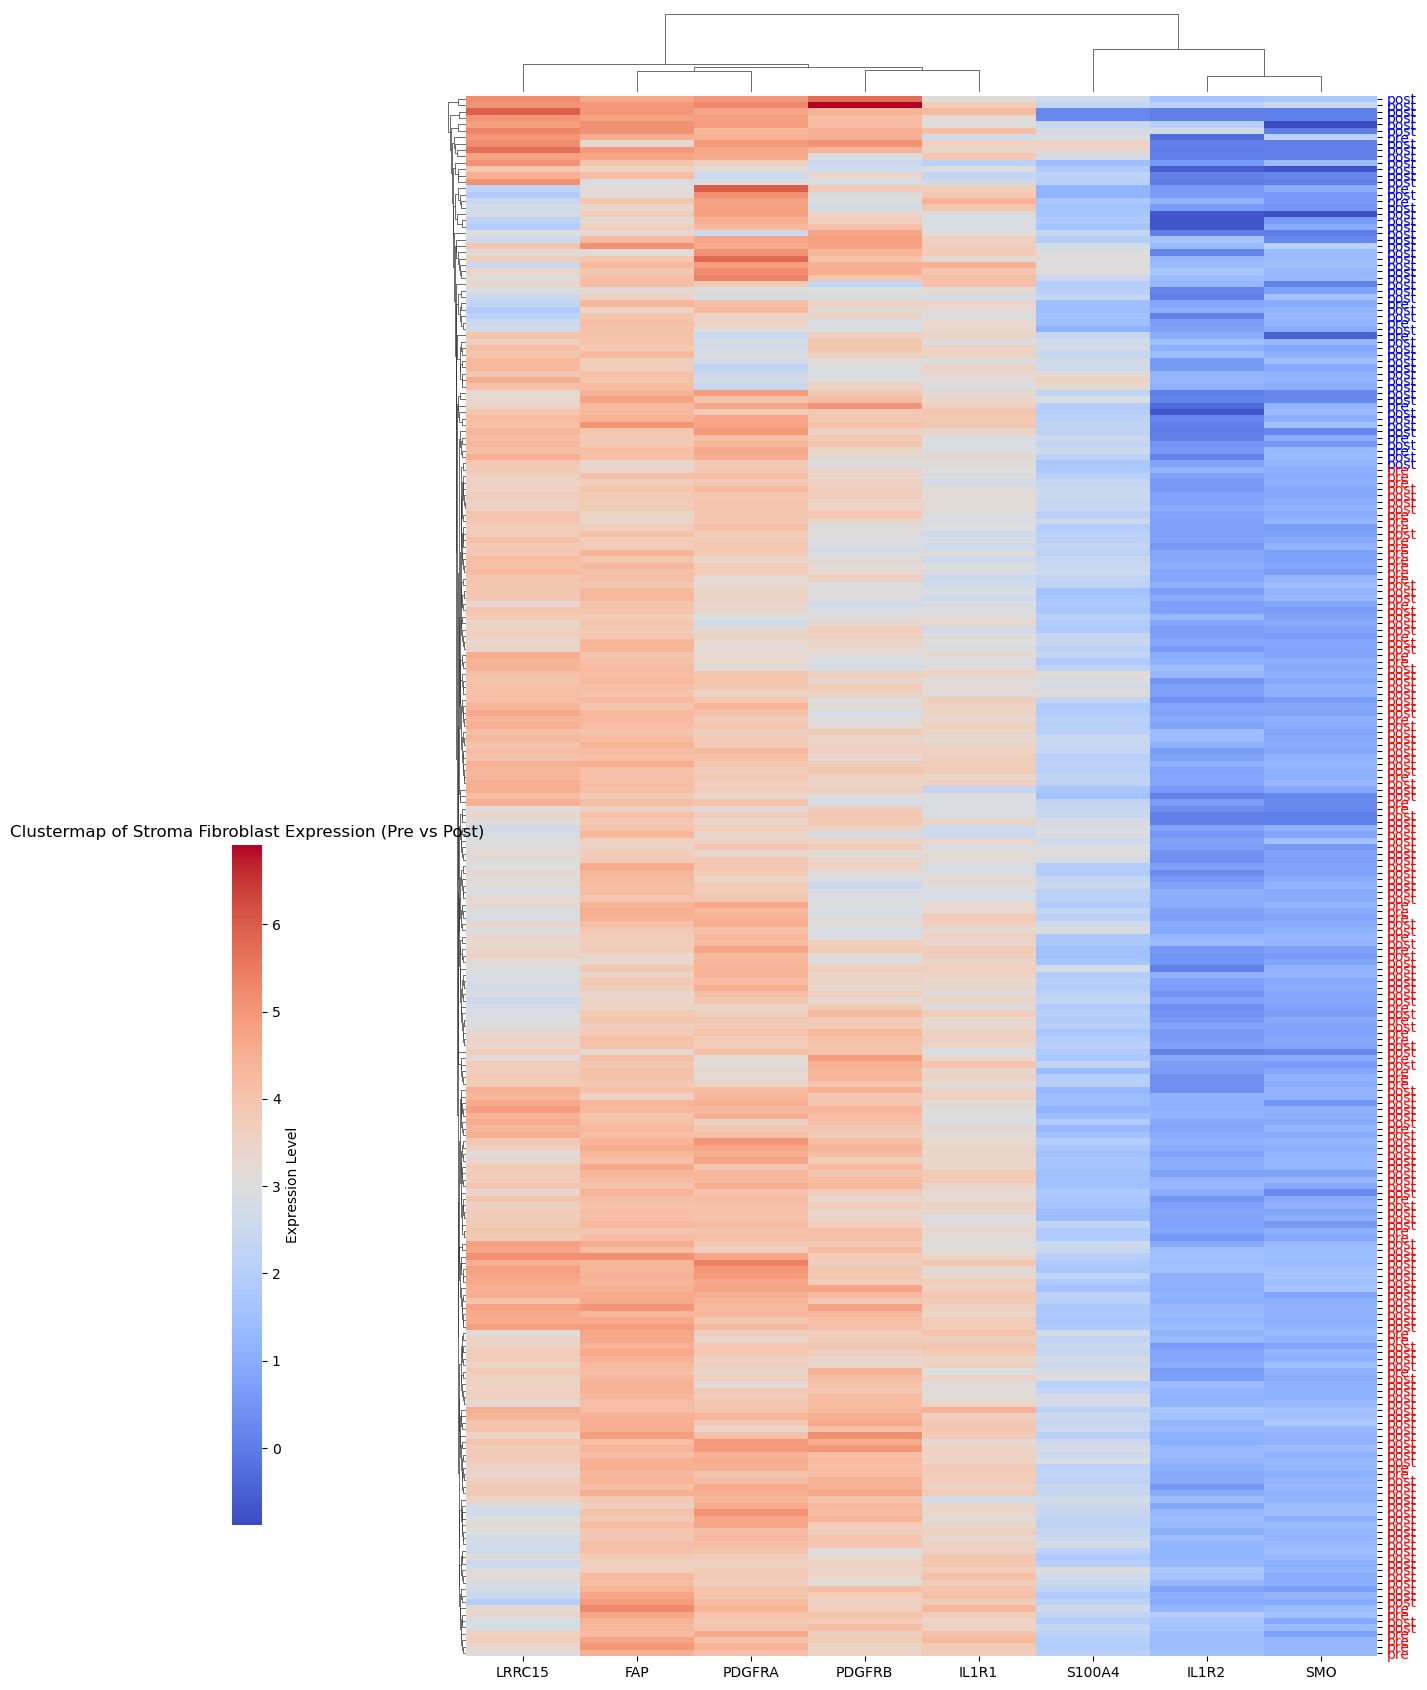

In [ ]:

# If they are already combined, skip this step
stroma_fibr_expr_matrix_combined = np.vstack([stroma_fibr_expr_matrix_pre, stroma_fibr_expr_matrix_post])

# Compute distance matrices
stroma_sample_dist = sch.distance.pdist(stroma_fibr_expr_matrix_combined, metric='euclidean')
stroma_gene_dist = sch.distance.pdist(stroma_fibr_expr_matrix_combined.T, metric='euclidean')

# Perform hierarchical clustering (using Ward method)
stroma_sample_linkage = sch.linkage(stroma_sample_dist, method='ward')
stroma_gene_linkage = sch.linkage(stroma_gene_dist, method='ward')

# Reorder the expression matrix according to the clustering order
sample_order = sch.leaves_list(stroma_sample_linkage)  # This is the order of the samples after clustering
gene_order = sch.leaves_list(stroma_gene_linkage)  # This is the order of the genes after clustering

# Create labels for pre and post samples
sample_labels = ['pre' if i < len(stroma_fibr_expr_matrix_pre) else 'post' for i in range(stroma_fibr_expr_matrix_combined.shape[0])]

color_map = {'pre': 'blue', 'post': 'red'}
ytick_colors = [color_map[label] for label in sample_labels]

# Create a clustermap using seaborn
g=sns.clustermap(
    stroma_fibr_expr_matrix_combined[sample_order, :][:, gene_order],  # Reordered expression matrix
    row_cluster=True,  # Cluster the rows (samples)
    col_cluster=True,  # Cluster the columns (genes)
    xticklabels=[target_CAF[i] for i in gene_order],  # Show gene names as labels on the x-axis
    yticklabels=[sample_labels[i] for i in sample_order],  # Row labels for pre/post
    cmap="coolwarm",  # Choose a colormap
    figsize=(10, 17),  # Set the size of the plot
    annot=False,  # Set to True if you want to annotate with expression values
    cbar_kws={'label': 'Expression Level'},  # Colorbar label
    dendrogram_ratio=(.02, .05),  # Adjust the ratio of the dendrogram height
    cbar_pos=(-0.2, .1, .03, .4),  # Position of the color bar
    #linewidths=0.03  # Add lines between cells for clarity
)

for label in g.ax_heatmap.get_yticklabels():
    if "pre" in label.get_text():  # If the label is "pre"
        label.set_color('red')  # Set color to red
    elif "post" in label.get_text():  # If the label is "post"
        label.set_color('blue')  
""""
# Add a colored rectangle next to y-ticks (this will represent the color for 'pre'/'post')
for i in range(len(sample_labels)):
    g.ax_heatmap.add_patch(plt.Rectangle(
        (0, i), 1, 1, color=ytick_colors[i], lw=0, zorder=-1))
"""

plt.title('Clustermap of Stroma Fibroblast Expression (Pre vs Post)')

plt.show()


In [26]:
numeric_fibr_expr_matrix = fibroblast_expr_matrix.values
numeric_fibr_expr_matrix=np.array(numeric_fibr_expr_matrix)
print(len(numeric_fibr_expr_matrix))

444


In [27]:
numeric_fibr_expr_matrix=np.array(fibroblast_expr_matrix)

In [28]:
# Ensure all values are floats (if they're not already)
numeric_fibr_expr_matrix = numeric_fibr_expr_matrix.astype(float)


In [29]:
#sch.distance.euclidean(numeric_fibr_expr_matrix[0],numeric_fibr_expr_matrix[1])
numeric_fibr_expr_matrix

array([[ 4.1720551 ,  3.99210515,  4.23357043, ...,  4.44917659,
         1.71355803,  1.53627995],
       [ 4.40031181,  3.9235966 ,  4.22020147, ...,  4.41335882,
         1.28676925,  1.40065995],
       [ 4.26100897,  3.74674718,  3.77733868, ...,  3.96886879,
        -0.70867123,  1.36465193],
       ...,
       [ 3.64853922,  3.68411874,  2.90620853, ...,  3.8588041 ,
        -0.1851834 , -0.28351163],
       [ 3.6698421 ,  4.05281871,  3.05817591, ...,  2.9857629 ,
         0.75813077,  0.64643346],
       [ 4.20004767,  4.63260484,  3.62400251, ...,  4.05217413,
         1.42867086,  0.75598254]])

In [30]:
# Compute the distance matrix for genes and samples
sample_dist = sch.distance.pdist(numeric_fibr_expr_matrix,metric='euclidean')
gene_dist = sch.distance.pdist(numeric_fibr_expr_matrix.T, metric='euclidean')

# Perform hierarchical clustering (using complete linkage)
sample_linkage = sch.linkage(sample_dist, method='ward')
gene_linkage = sch.linkage(gene_dist, method='ward')

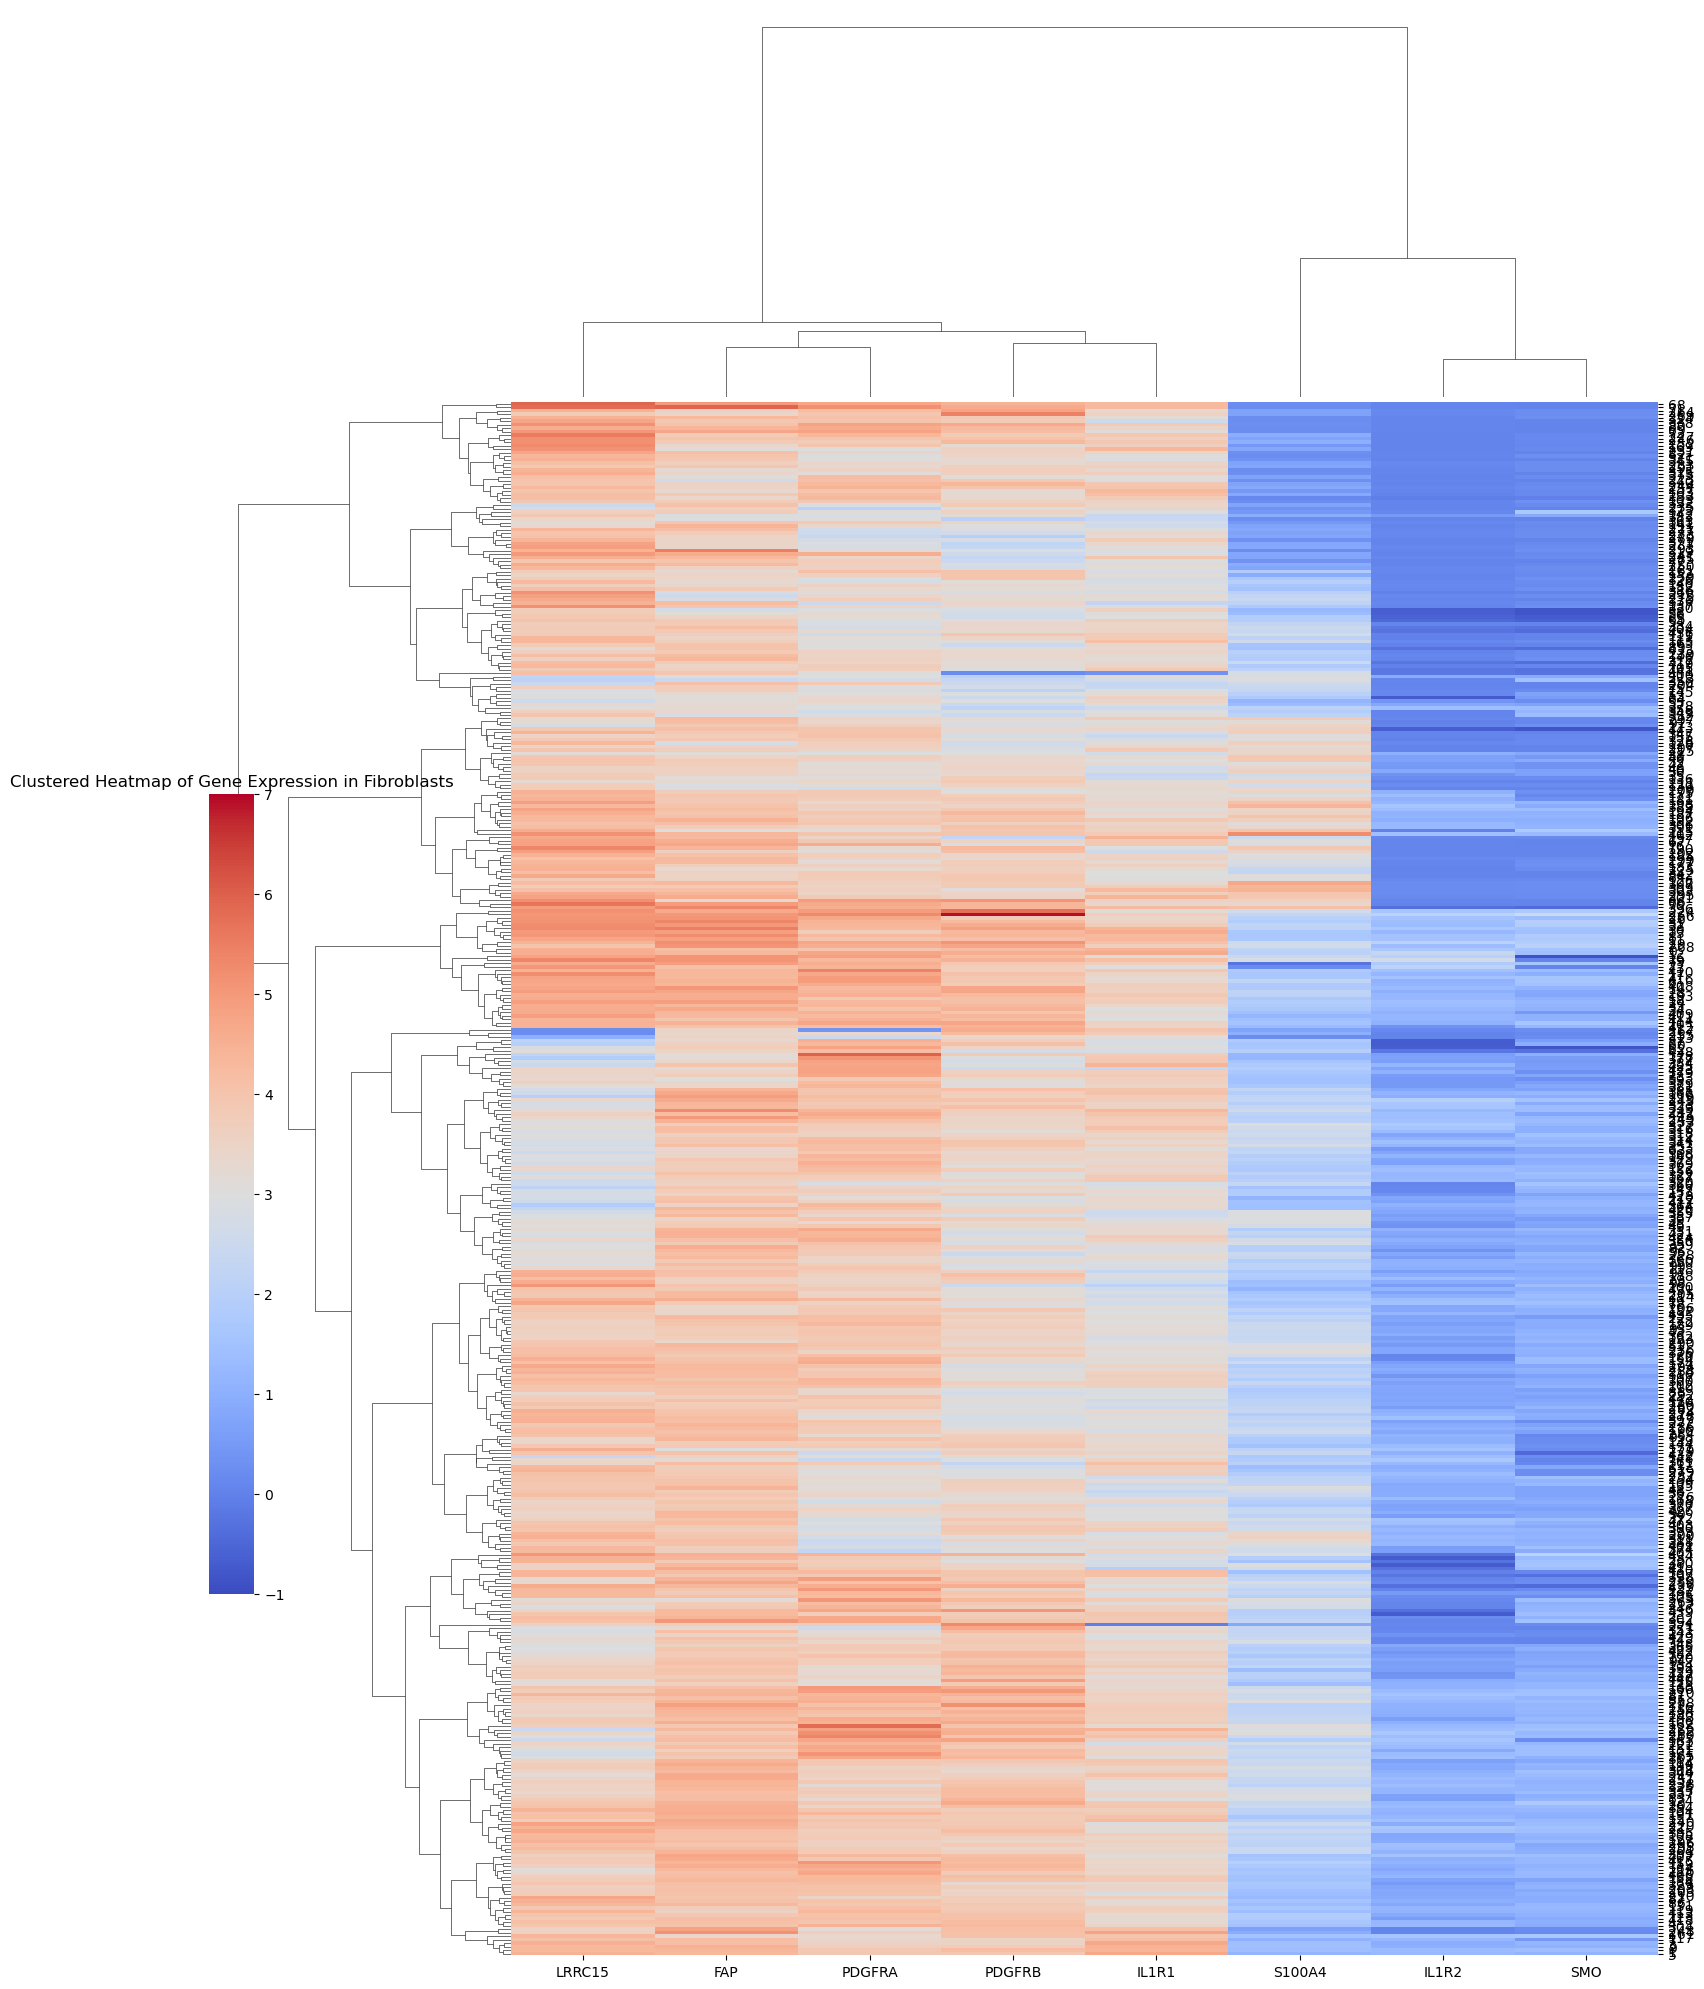

In [31]:
sns.clustermap(
    numeric_fibr_expr_matrix,  # The expression matrix (samples as rows, genes as columns)
    row_linkage=sample_linkage, 
    col_linkage=gene_linkage,  # Clustering of samples,  # Clustering of genes
    cmap='coolwarm',  # Color map for heatmap
     figsize=(15, 20),  # Size of the plot
    xticklabels=target_CAF,  # Show gene names as labels on the x-axis
    yticklabels=True,  # Show sample names as labels on the y-axis
    cbar_pos=(0, .2, .03, .4),  # Color bar position adjustments
    annot=False,
    vmin=-1,
    vmax=7 # Set to True if you want to annotate each cell with the actual expression value
)

# Display the heatmap
plt.title("Clustered Heatmap of Gene Expression in Fibroblasts")
plt.show()

In [32]:
# Filter for "tumor" segment
tumor_fibr_expr_matrix = fibr_gene_expression_modified.loc[fibr_gene_expression_modified["Segment"] == "tumor"]
samples=tumor_fibr_expr_matrix["Sample"]
# Select the target genes related to CAF (target_CAF)
tumor_fibr_expr_matrix = tumor_fibr_expr_matrix.loc[:, target_CAF]

# Ensure all values are floats (if they're not already)
tumor_fibr_expr_matrix = tumor_fibr_expr_matrix.values
tumor_fibr_expr_matrix = np.array(tumor_fibr_expr_matrix)
tumor_fibr_expr_matrix = tumor_fibr_expr_matrix.astype(float)

# Compute the distance matrix for genes and samples
tumor_sample_dist = sch.distance.pdist(tumor_fibr_expr_matrix, metric='euclidean')
tumor_gene_dist = sch.distance.pdist(tumor_fibr_expr_matrix.T, metric='euclidean')

# Perform hierarchical clustering (using complete linkage)
tumor_sample_linkage = sch.linkage(tumor_sample_dist, method='ward')
tumor_gene_linkage = sch.linkage(tumor_gene_dist, method='ward')




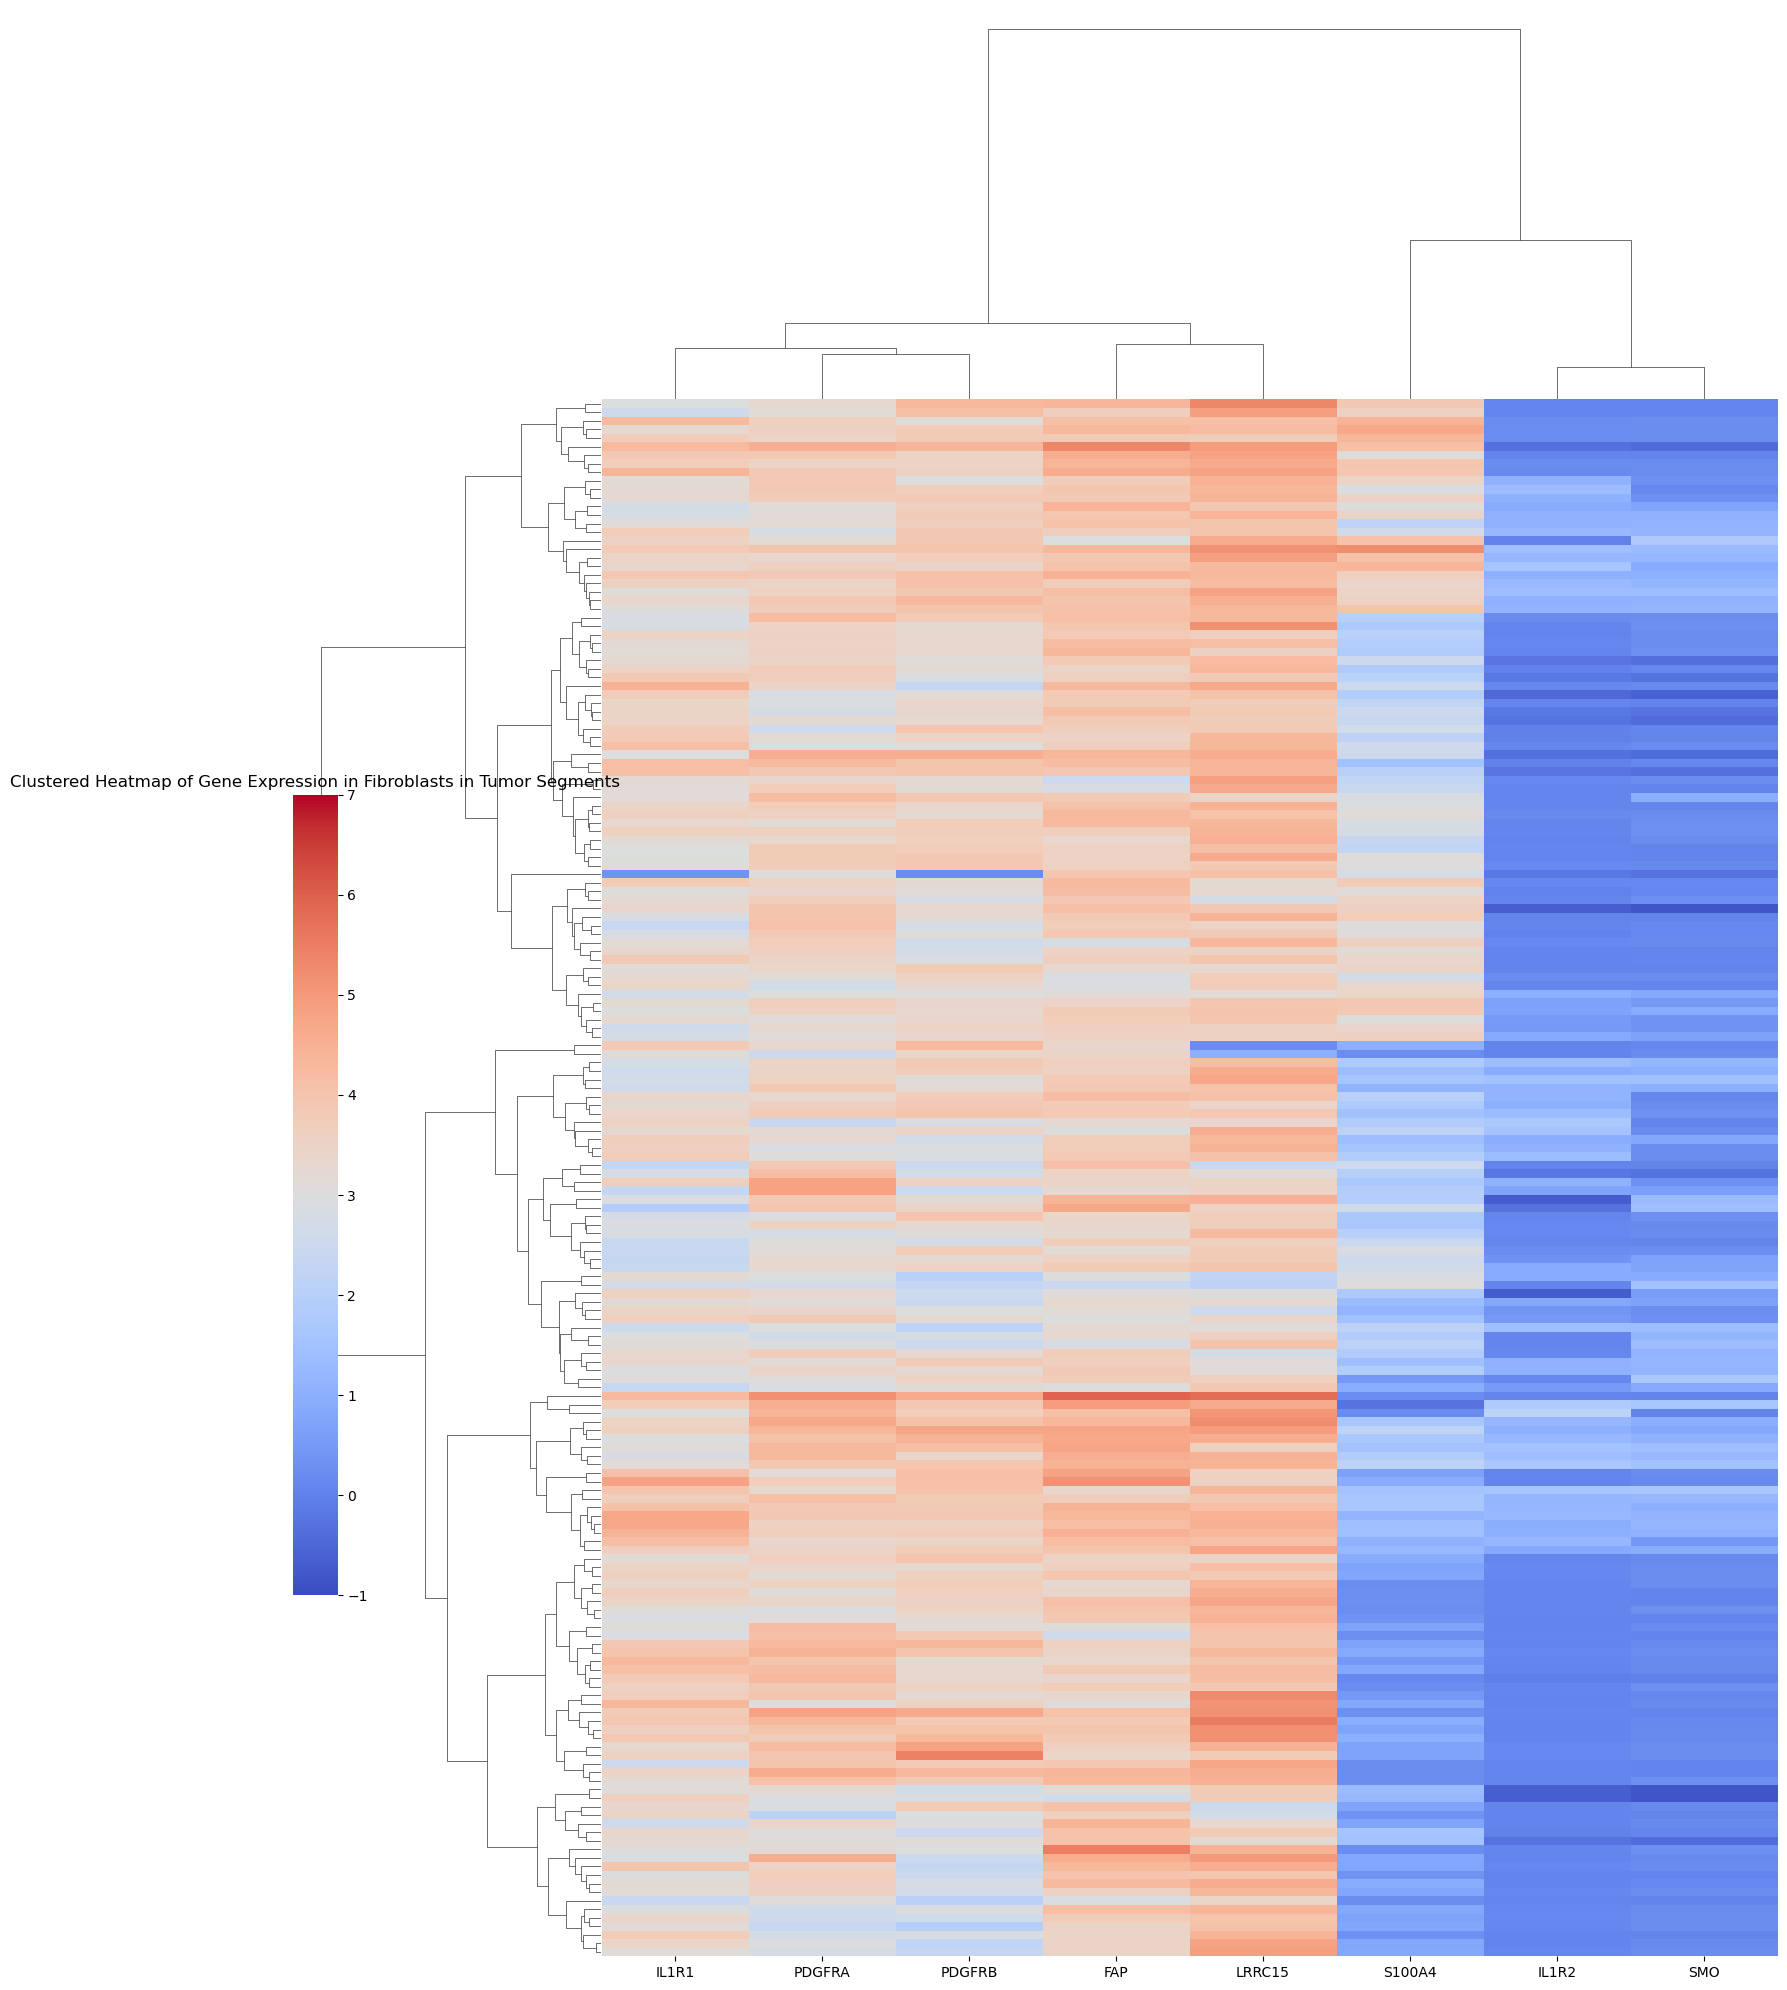

In [33]:

#lut = dict(zip(samples.values.unique(), "rbg"))
#row_colors = samples.values.map(lut)

sns.clustermap(
    tumor_fibr_expr_matrix,  # The expression matrix (samples as rows, genes as columns)
    row_linkage=tumor_sample_linkage, 
    col_linkage=tumor_gene_linkage,  # Clustering of samples,  # Clustering of genes
    cmap='coolwarm',  # Color map for heatmap
    figsize=(15, 20),  # Size of the plot
    xticklabels=target_CAF,  # Show gene names as labels on the x-axis
    yticklabels=False,  # Show sample names as labels on the y-axis
    cbar_pos=(0, .2, .03, .4),  # Color bar position adjustments
    annot=False,
    vmin=-1,
    vmax=7  # Set to True if you want to annotate each cell with the actual expression value
)

# Display the heatmap
plt.title("Clustered Heatmap of Gene Expression in Fibroblasts in Tumor Segments")
plt.show()


Hierarchial clustering for the caf derived factors and receptor genes

In [34]:
fibroblast_expr_matrix_derived = fibr_gene_expression_modified.loc[:,cafs_factors_receptors]
fibroblast_expr_matrix_derived

,TGFB1,TGFB2,TGFB3,TGFBR1,TGFBR2,TGFBR3,IL6,IL6R,IL10RA,IL10RB,...,FGF10,FGFR1,FGFR2,FGFR3,FGFR4,IL11,HAS1,HAS2,HYAL1,HYAL2
0,1.939605,2.902472,2.623848,2.543082,2.035924,1.677488,3.373226,1.484549,0.061000,-0.540546,...,4.169280,3.771202,1.688956,-0.159230,-0.005221,3.607444,4.453848,3.488071,1.587136,2.856606
1,1.813175,2.724433,3.430841,2.069089,1.906135,1.546341,3.397471,1.350294,0.062444,1.085189,...,4.367715,3.759930,1.265182,0.936641,1.091837,2.758130,4.096922,3.065283,1.164360,2.182041
2,1.754419,2.988813,3.300869,1.577196,1.855707,1.499229,3.306326,1.310933,0.058912,1.710241,...,3.996231,3.850644,-0.737693,-0.158687,-0.006398,2.419936,3.732296,2.068419,1.408408,1.890555
3,1.584421,2.813591,2.939928,1.938474,1.677789,1.318161,3.014015,1.122489,0.062267,1.142188,...,4.020037,3.686467,0.945864,0.979838,-0.004506,2.549242,3.594314,2.580904,1.228092,2.011614
4,1.436880,2.524108,3.797038,1.973253,1.530446,1.170904,3.570822,0.975410,0.062176,1.378195,...,4.146550,2.296875,1.181811,-0.159533,-0.004557,2.357110,3.869599,2.536286,1.080815,1.568162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,1.880165,2.288663,3.570418,1.473575,2.199560,1.233155,2.648548,-0.020269,-0.183192,-0.253801,...,3.604561,2.880048,1.151493,-0.220619,-0.098678,2.787448,4.372825,2.680130,1.348250,2.490434
440,1.932271,1.235988,2.938251,1.275500,1.781873,0.348320,1.469574,0.702454,0.539132,0.863799,...,2.098865,2.146880,1.199666,0.501479,-0.098717,1.490110,1.318232,1.831912,0.855020,1.966975
441,-0.093140,2.773574,2.441446,0.148429,0.171597,-0.613719,3.012080,-0.005727,-0.131094,-0.155585,...,4.003470,3.603432,2.044237,-0.146442,-0.093509,2.789003,2.901087,2.296899,-0.096184,0.026136
442,1.589499,1.854556,2.549616,1.473517,1.909138,0.708946,1.220518,-0.020333,-0.183443,1.357186,...,2.571307,2.088814,1.528113,-0.220976,-0.098698,1.686607,2.885172,1.916826,0.822100,1.762698


In [35]:
stroma_fibr_expr_matrix=fibr_gene_expression_modified.loc[fibr_gene_expression_modified["Segment"]=="stroma"]
stroma_fibr_expr_matrix=stroma_fibr_expr_matrix.loc[:,cafs_factors_receptors]
# Ensure all values are floats (if they're not already)
stroma_fibr_expr_matrix = stroma_fibr_expr_matrix.values
stroma_fibr_expr_matrix=np.array(stroma_fibr_expr_matrix)
stroma_fibr_expr_matrix= stroma_fibr_expr_matrix.astype(float)

# Compute the distance matrix for genes and samples
stroma_sample_dist = sch.distance.pdist(stroma_fibr_expr_matrix,metric='euclidean')
stroma_gene_dist = sch.distance.pdist(stroma_fibr_expr_matrix.T, metric='euclidean')

# Perform hierarchical clustering (using complete linkage)
stroma_sample_linkage = sch.linkage(stroma_sample_dist, method='ward')
stroma_gene_linkage = sch.linkage(stroma_gene_dist, method='ward')


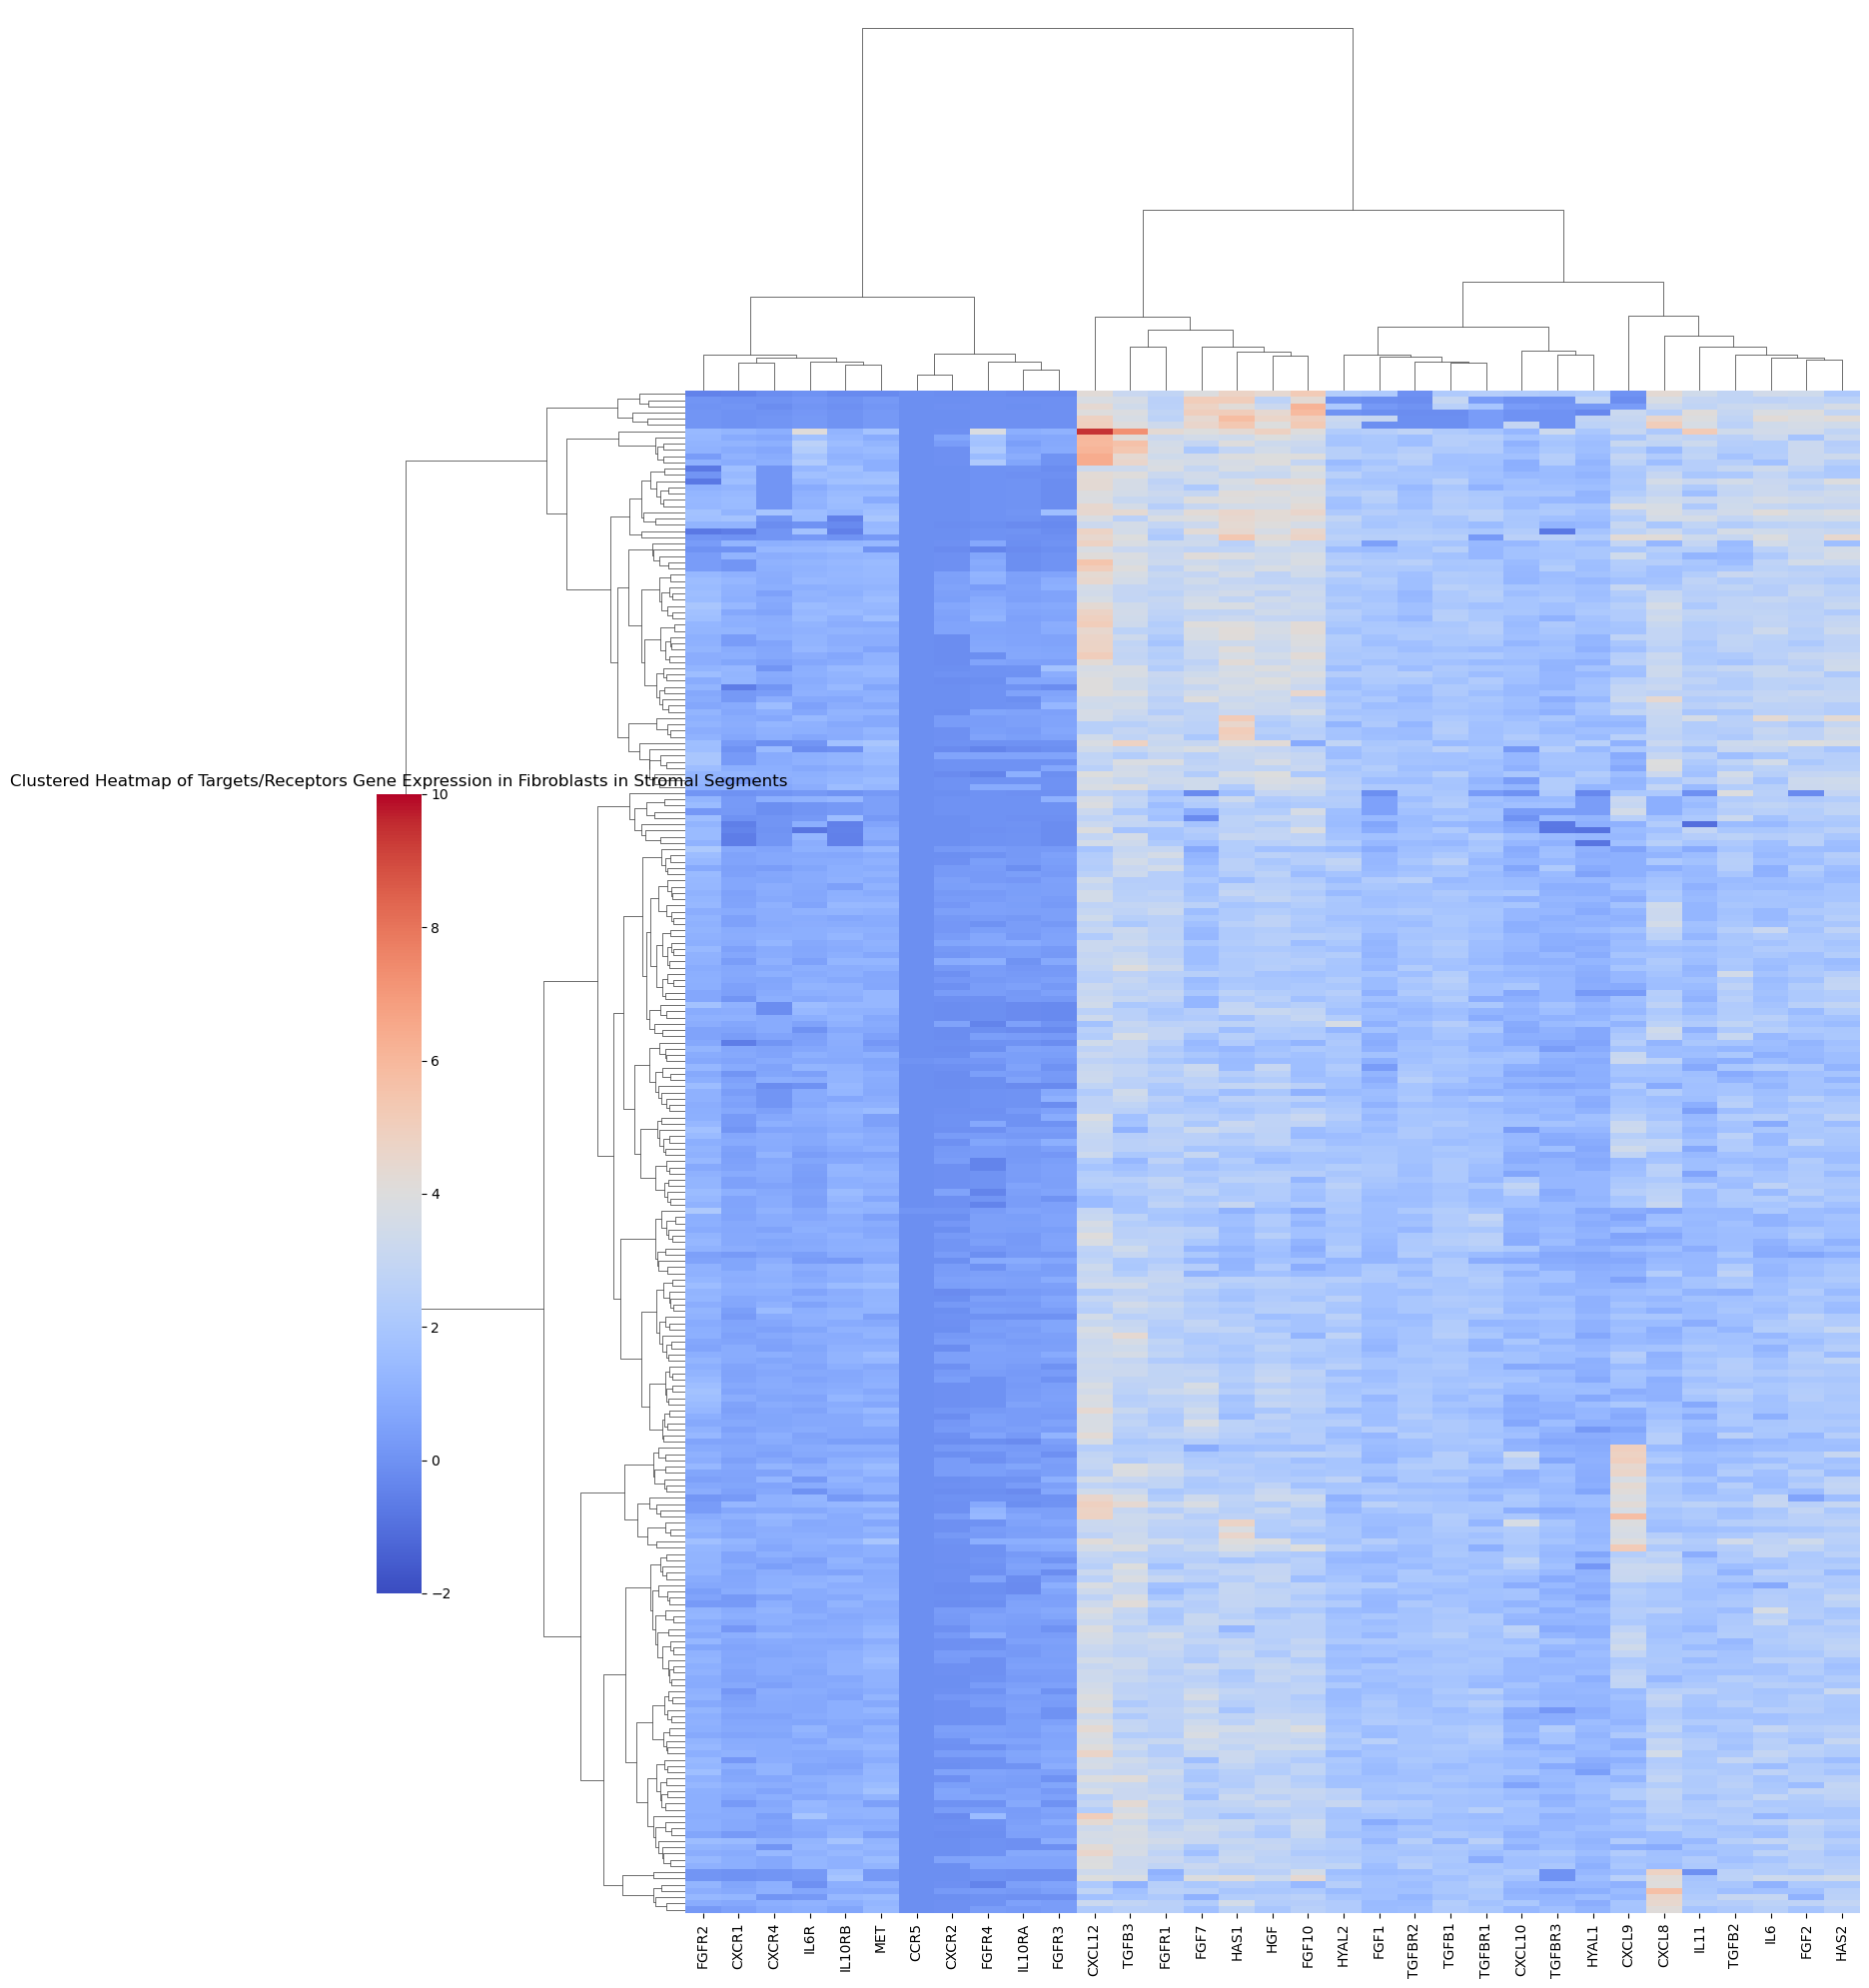

In [36]:
sns.clustermap(
    stroma_fibr_expr_matrix,  # The expression matrix (samples as rows, genes as columns)
    row_linkage=stroma_sample_linkage, 
    col_linkage=stroma_gene_linkage,  # Clustering of samples,  # Clustering of genes
    cmap='coolwarm',  # Color map for heatmap
    figsize=(15, 20),  # Size of the plot
    xticklabels=cafs_factors_receptors,  # Show gene names as labels on the x-axis
    yticklabels=False,  # Show sample names as labels on the y-axis
    cbar_pos=(0, .2, .03, .4), 
    vmin=-2, # Color bar position adjustments
    vmax=10 # Set to True if you want to annotate each cell with the actual expression value
)

# Display the heatmap
plt.title("Clustered Heatmap of Targets/Receptors Gene Expression in Fibroblasts in Stromal Segments")
plt.show()

In [37]:
# Filter for "tumor" segment
tumor_fibr_expr_matrix = fibr_gene_expression_modified.loc[fibr_gene_expression_modified["Segment"] == "tumor"]
samples=tumor_fibr_expr_matrix["Sample"]
# Select the target genes related to CAF (target_CAF)
tumor_fibr_expr_matrix = tumor_fibr_expr_matrix.loc[:, cafs_factors_receptors]

# Ensure all values are floats (if they're not already)
tumor_fibr_expr_matrix = tumor_fibr_expr_matrix.values
tumor_fibr_expr_matrix = np.array(tumor_fibr_expr_matrix)
tumor_fibr_expr_matrix = tumor_fibr_expr_matrix.astype(float)

# Compute the distance matrix for genes and samples
tumor_sample_dist = sch.distance.pdist(tumor_fibr_expr_matrix, metric='euclidean')
tumor_gene_dist = sch.distance.pdist(tumor_fibr_expr_matrix.T, metric='euclidean')

# Perform hierarchical clustering (using complete linkage)
tumor_sample_linkage = sch.linkage(tumor_sample_dist, method='ward')
tumor_gene_linkage = sch.linkage(tumor_gene_dist, method='ward')

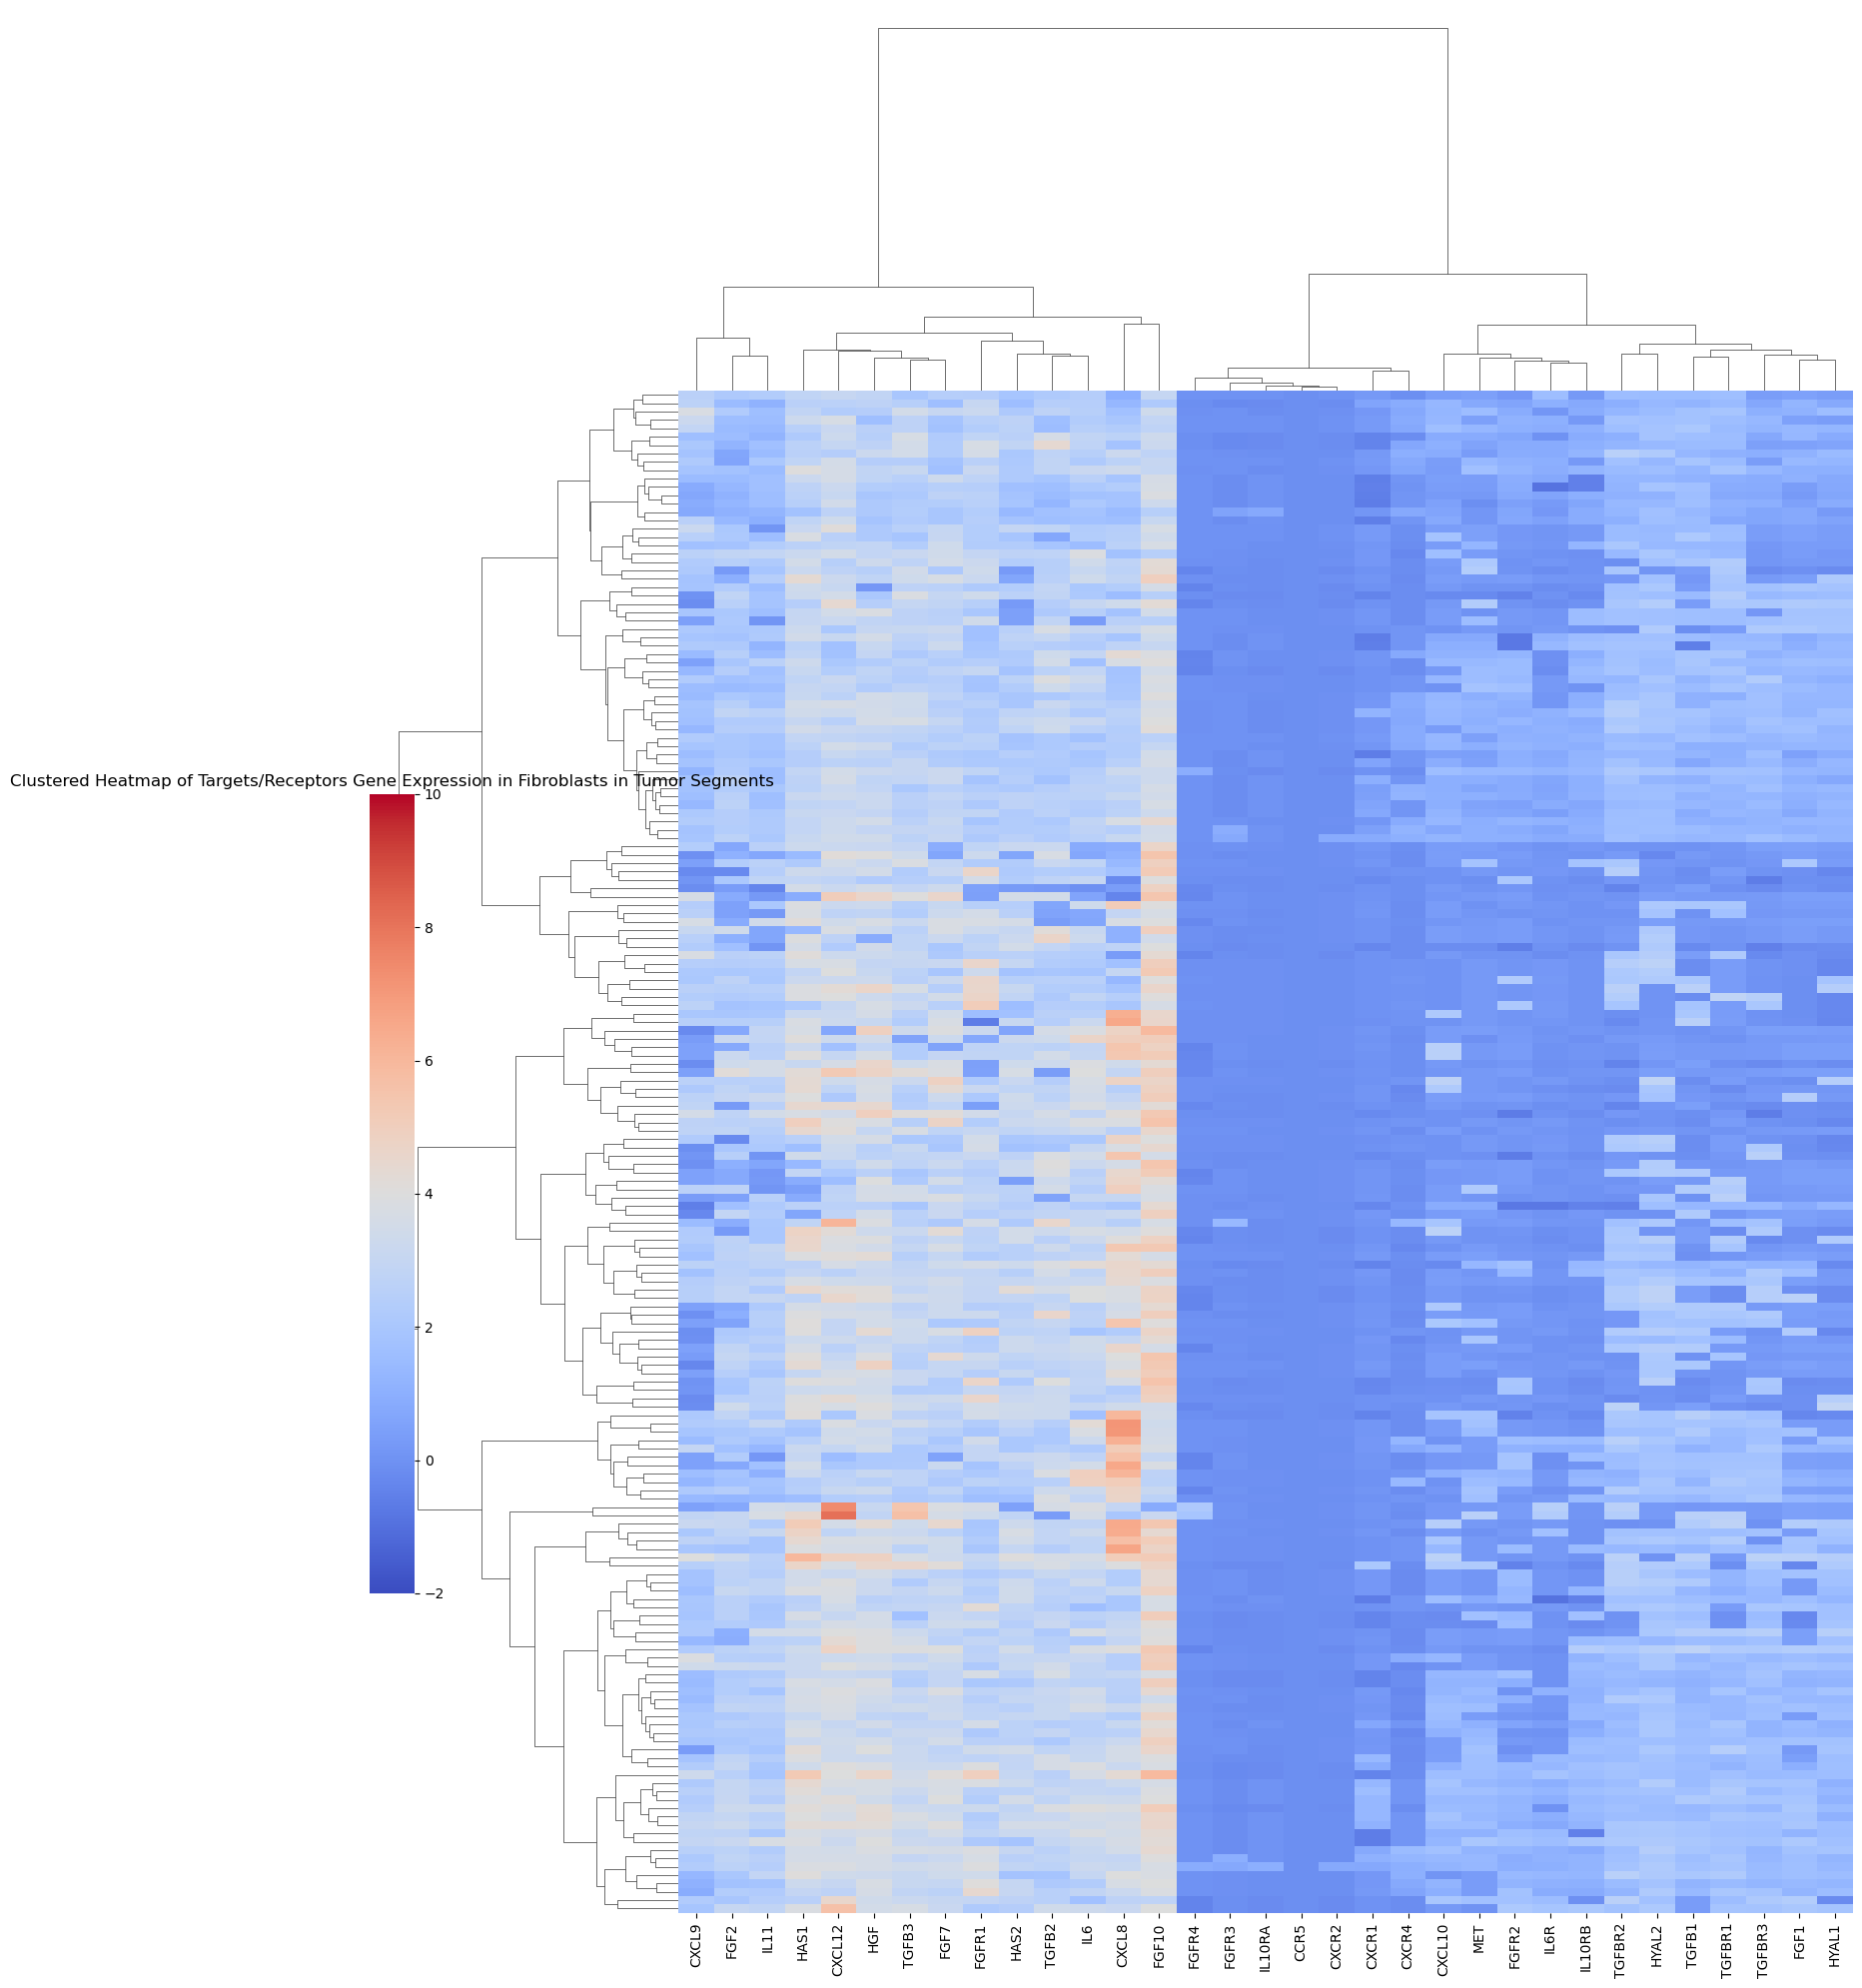

In [38]:
sns.clustermap(
    tumor_fibr_expr_matrix,  # The expression matrix (samples as rows, genes as columns)
    row_linkage=tumor_sample_linkage, 
    col_linkage=tumor_gene_linkage,  # Clustering of samples,  # Clustering of genes
    cmap='coolwarm',  # Color map for heatmap
    figsize=(15, 20),  # Size of the plot
    xticklabels=cafs_factors_receptors,  # Show gene names as labels on the x-axis
    yticklabels=False,  # Show sample names as labels on the y-axis
    cbar_pos=(0, .2, .03, .4), 
    vmin=-2, # Color bar position adjustments
    vmax=10 # Set to True if you want to annotate each cell with the actual expression value
)

# Display the heatmap
plt.title("Clustered Heatmap of Targets/Receptors Gene Expression in Fibroblasts in Tumor Segments")
plt.show()

Clustered heatmap of whole gene expression in the stromal segment

In [39]:
stromal_gene_expression=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/batch_merged_geomx_harmony_corr_expr_transpose.csv")
stromal_gene_expression



,dcc_filename,A2M,ACADM,ACADS,ACAT1,ACVRL1,PSEN1,ADA,SGCA,ADRB2,...,RPEL1,SLC12A6,SPATA21,SYCP2L,FGF10,IL3,IL5,MBL2,ARG1,CCL7
0,DSP.1001660016606.G.A02.dcc,6.804666,3.813770,3.094522,3.164409,3.379704,4.040574,2.899794,3.971268,1.660338,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,DSP.1001660016606.G.A03.dcc,6.260479,4.098920,2.754026,3.695262,3.204526,4.713780,2.037078,3.807079,1.459433,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DSP.1001660016606.G.A04.dcc,6.558231,3.995816,3.354820,3.765523,2.918882,3.908741,3.160093,3.933863,2.369323,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DSP.1001660016606.G.A05.dcc,6.372312,3.182476,2.866057,3.848748,1.562825,4.439850,2.001105,4.093993,1.666247,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,DSP.1001660016606.G.A06.dcc,7.417367,3.226799,2.810282,4.366523,3.352077,3.631273,2.465758,3.329628,1.619624,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,DSP.1001660037247.C.D02.dcc,8.166184,5.241664,3.124489,3.526732,3.990766,4.529707,2.097933,3.164388,2.191627,...,1.682951,2.486022,1.303624,4.220623,3.404106,1.639313,0.528117,1.784708,1.268932,1.171722
500,DSP.1001660037247.C.D03.dcc,6.376363,5.552360,2.214444,5.236922,3.291828,5.162804,1.452677,2.908834,0.359455,...,2.603953,1.448833,1.971167,2.171534,1.837595,0.993433,2.067794,3.294537,0.338434,0.994699
501,DSP.1001660037247.C.D04.dcc,5.965432,4.531758,3.336801,4.182140,4.394296,2.165280,3.052810,0.851340,2.393427,...,3.660318,2.696280,1.463408,2.607464,3.337978,2.273930,4.099109,1.475635,1.923790,1.826580
502,DSP.1001660037247.C.D05.dcc,4.274683,4.829125,4.450223,5.702187,2.662740,5.174575,2.488751,3.088751,0.339813,...,2.165921,2.484907,2.905090,1.682048,2.462543,2.462948,0.763774,0.365711,2.561423,0.535245


In [40]:
metadata_merged=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/batch_merged_geomx_metadata.csv")
metadata_merged["dcc_filename"]= metadata_merged['dcc_filename'].str.replace('-', '.', regex=False)
metadata_merged

,dcc_filename,Slide_Name,Sample,Segment,Roi,Aoi,area,nuclei,NACT_status,Patient,Site,Annotation_cell,UMAP1_harmony_batch_corr,UMAP2_harmony_batch_corr,tSNE1_harmony_batch_corr,tSNE2_harmony_batch_corr,PFS_quartile,OS_quartile,HRP_status,BRCA_status
0,DSP.1001660016606.G.A02.dcc,NACT_TSI_2022_Batch8_13097-57209_140623,S053_post,stroma,1,stroma-aoi-001,27922.80,227,post,S053,Omentum,posCD8_posIBA1,0.794573,-3.189869,-3.847626,-6.147862,1,1,1.0,0.0
1,DSP.1001660016606.G.A03.dcc,NACT_TSI_2022_Batch8_13097-57209_140623,S053_post,tumor,1,tumor-aoi-001,19023.63,131,post,S053,Omentum,posCD8_posIBA1,2.214970,4.387641,-0.483552,10.893174,1,1,1.0,0.0
2,DSP.1001660016606.G.A04.dcc,NACT_TSI_2022_Batch8_13097-57209_140623,S053_post,stroma,2,stroma-aoi-001,33159.35,188,post,S053,Omentum,posCD8_posIBA1,1.085109,-3.414700,-3.420880,-5.879995,1,1,1.0,0.0
3,DSP.1001660016606.G.A05.dcc,NACT_TSI_2022_Batch8_13097-57209_140623,S053_post,tumor,2,tumor-aoi-001,21852.52,139,post,S053,Omentum,posCD8_posIBA1,2.348271,4.468682,-0.820358,11.383190,1,1,1.0,0.0
4,DSP.1001660016606.G.A06.dcc,NACT_TSI_2022_Batch8_13097-57209_140623,S053_post,stroma,3,stroma-aoi-001,38863.40,189,post,S053,Omentum,posCD8_posIBA1,1.287827,-3.338168,-3.264500,-5.409131,1,1,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,DSP.1001660037247.C.D02.dcc,S333_S069_3,S333_pOme,stroma,18,stroma-aoi-001,21430.51,200,pre,S333,Omentum,CD8_CD11_Iba1,-1.239031,-0.703740,4.600234,-4.362463,3,1,1.0,0.0
500,DSP.1001660037247.C.D03.dcc,S333_S069_3,S333_pOme,tumor,18,tumor-aoi-001,18603.52,191,pre,S333,Omentum,CD8_CD11_Iba1,-0.745955,3.245862,-0.746496,9.353104,3,1,1.0,0.0
501,DSP.1001660037247.C.D04.dcc,S333_S069_3,S333_pOme,stroma,19,stroma-aoi-001,29715.75,231,pre,S333,Omentum,CD8_CD11_Iba1,0.277125,0.801534,4.179252,-5.604464,3,1,1.0,0.0
502,DSP.1001660037247.C.D05.dcc,S333_S069_3,S333_pOme,tumor,19,tumor-aoi-001,21579.00,188,pre,S333,Omentum,CD8_CD11_Iba1,-0.689251,3.103328,0.152544,10.158832,3,1,1.0,0.0


In [41]:
stromal_gene_expression=stromal_gene_expression.merge(metadata_merged[['dcc_filename', 'Segment']], on='dcc_filename', how='left')
stromal_gene_expression

,dcc_filename,A2M,ACADM,ACADS,ACAT1,ACVRL1,PSEN1,ADA,SGCA,ADRB2,...,SLC12A6,SPATA21,SYCP2L,FGF10,IL3,IL5,MBL2,ARG1,CCL7,Segment
0,DSP.1001660016606.G.A02.dcc,6.804666,3.813770,3.094522,3.164409,3.379704,4.040574,2.899794,3.971268,1.660338,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stroma
1,DSP.1001660016606.G.A03.dcc,6.260479,4.098920,2.754026,3.695262,3.204526,4.713780,2.037078,3.807079,1.459433,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tumor
2,DSP.1001660016606.G.A04.dcc,6.558231,3.995816,3.354820,3.765523,2.918882,3.908741,3.160093,3.933863,2.369323,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stroma
3,DSP.1001660016606.G.A05.dcc,6.372312,3.182476,2.866057,3.848748,1.562825,4.439850,2.001105,4.093993,1.666247,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tumor
4,DSP.1001660016606.G.A06.dcc,7.417367,3.226799,2.810282,4.366523,3.352077,3.631273,2.465758,3.329628,1.619624,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stroma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,DSP.1001660037247.C.D02.dcc,8.166184,5.241664,3.124489,3.526732,3.990766,4.529707,2.097933,3.164388,2.191627,...,2.486022,1.303624,4.220623,3.404106,1.639313,0.528117,1.784708,1.268932,1.171722,stroma
500,DSP.1001660037247.C.D03.dcc,6.376363,5.552360,2.214444,5.236922,3.291828,5.162804,1.452677,2.908834,0.359455,...,1.448833,1.971167,2.171534,1.837595,0.993433,2.067794,3.294537,0.338434,0.994699,tumor
501,DSP.1001660037247.C.D04.dcc,5.965432,4.531758,3.336801,4.182140,4.394296,2.165280,3.052810,0.851340,2.393427,...,2.696280,1.463408,2.607464,3.337978,2.273930,4.099109,1.475635,1.923790,1.826580,stroma
502,DSP.1001660037247.C.D05.dcc,4.274683,4.829125,4.450223,5.702187,2.662740,5.174575,2.488751,3.088751,0.339813,...,2.484907,2.905090,1.682048,2.462543,2.462948,0.763774,0.365711,2.561423,0.535245,tumor


In [42]:
# Filter for "tumor" segment
stroma_expr_matrix = stromal_gene_expression.loc[stromal_gene_expression["Segment"] == "stroma"]
#samples=stroma_expr_matrix["Sample"]
# Select the target genes related to CAF (target_CAF)
stroma_expr_matrix = stroma_expr_matrix.loc[:, target_CAF]

# Ensure all values are floats (if they're not already)
stroma_expr_matrix = stroma_expr_matrix.values
stroma_expr_matrix = np.array(stroma_expr_matrix)
stroma_expr_matrix = stroma_expr_matrix.astype(float)

# Compute the distance matrix for genes and samples
stroma_sample_dist = sch.distance.pdist(stroma_expr_matrix, metric='euclidean')
stroma_gene_dist = sch.distance.pdist(stroma_expr_matrix.T, metric='euclidean')

# Perform hierarchical clustering (using complete linkage)
stroma_sample_linkage = sch.linkage(stroma_sample_dist, method='ward')
stroma_gene_linkage = sch.linkage(stroma_gene_dist, method='ward')

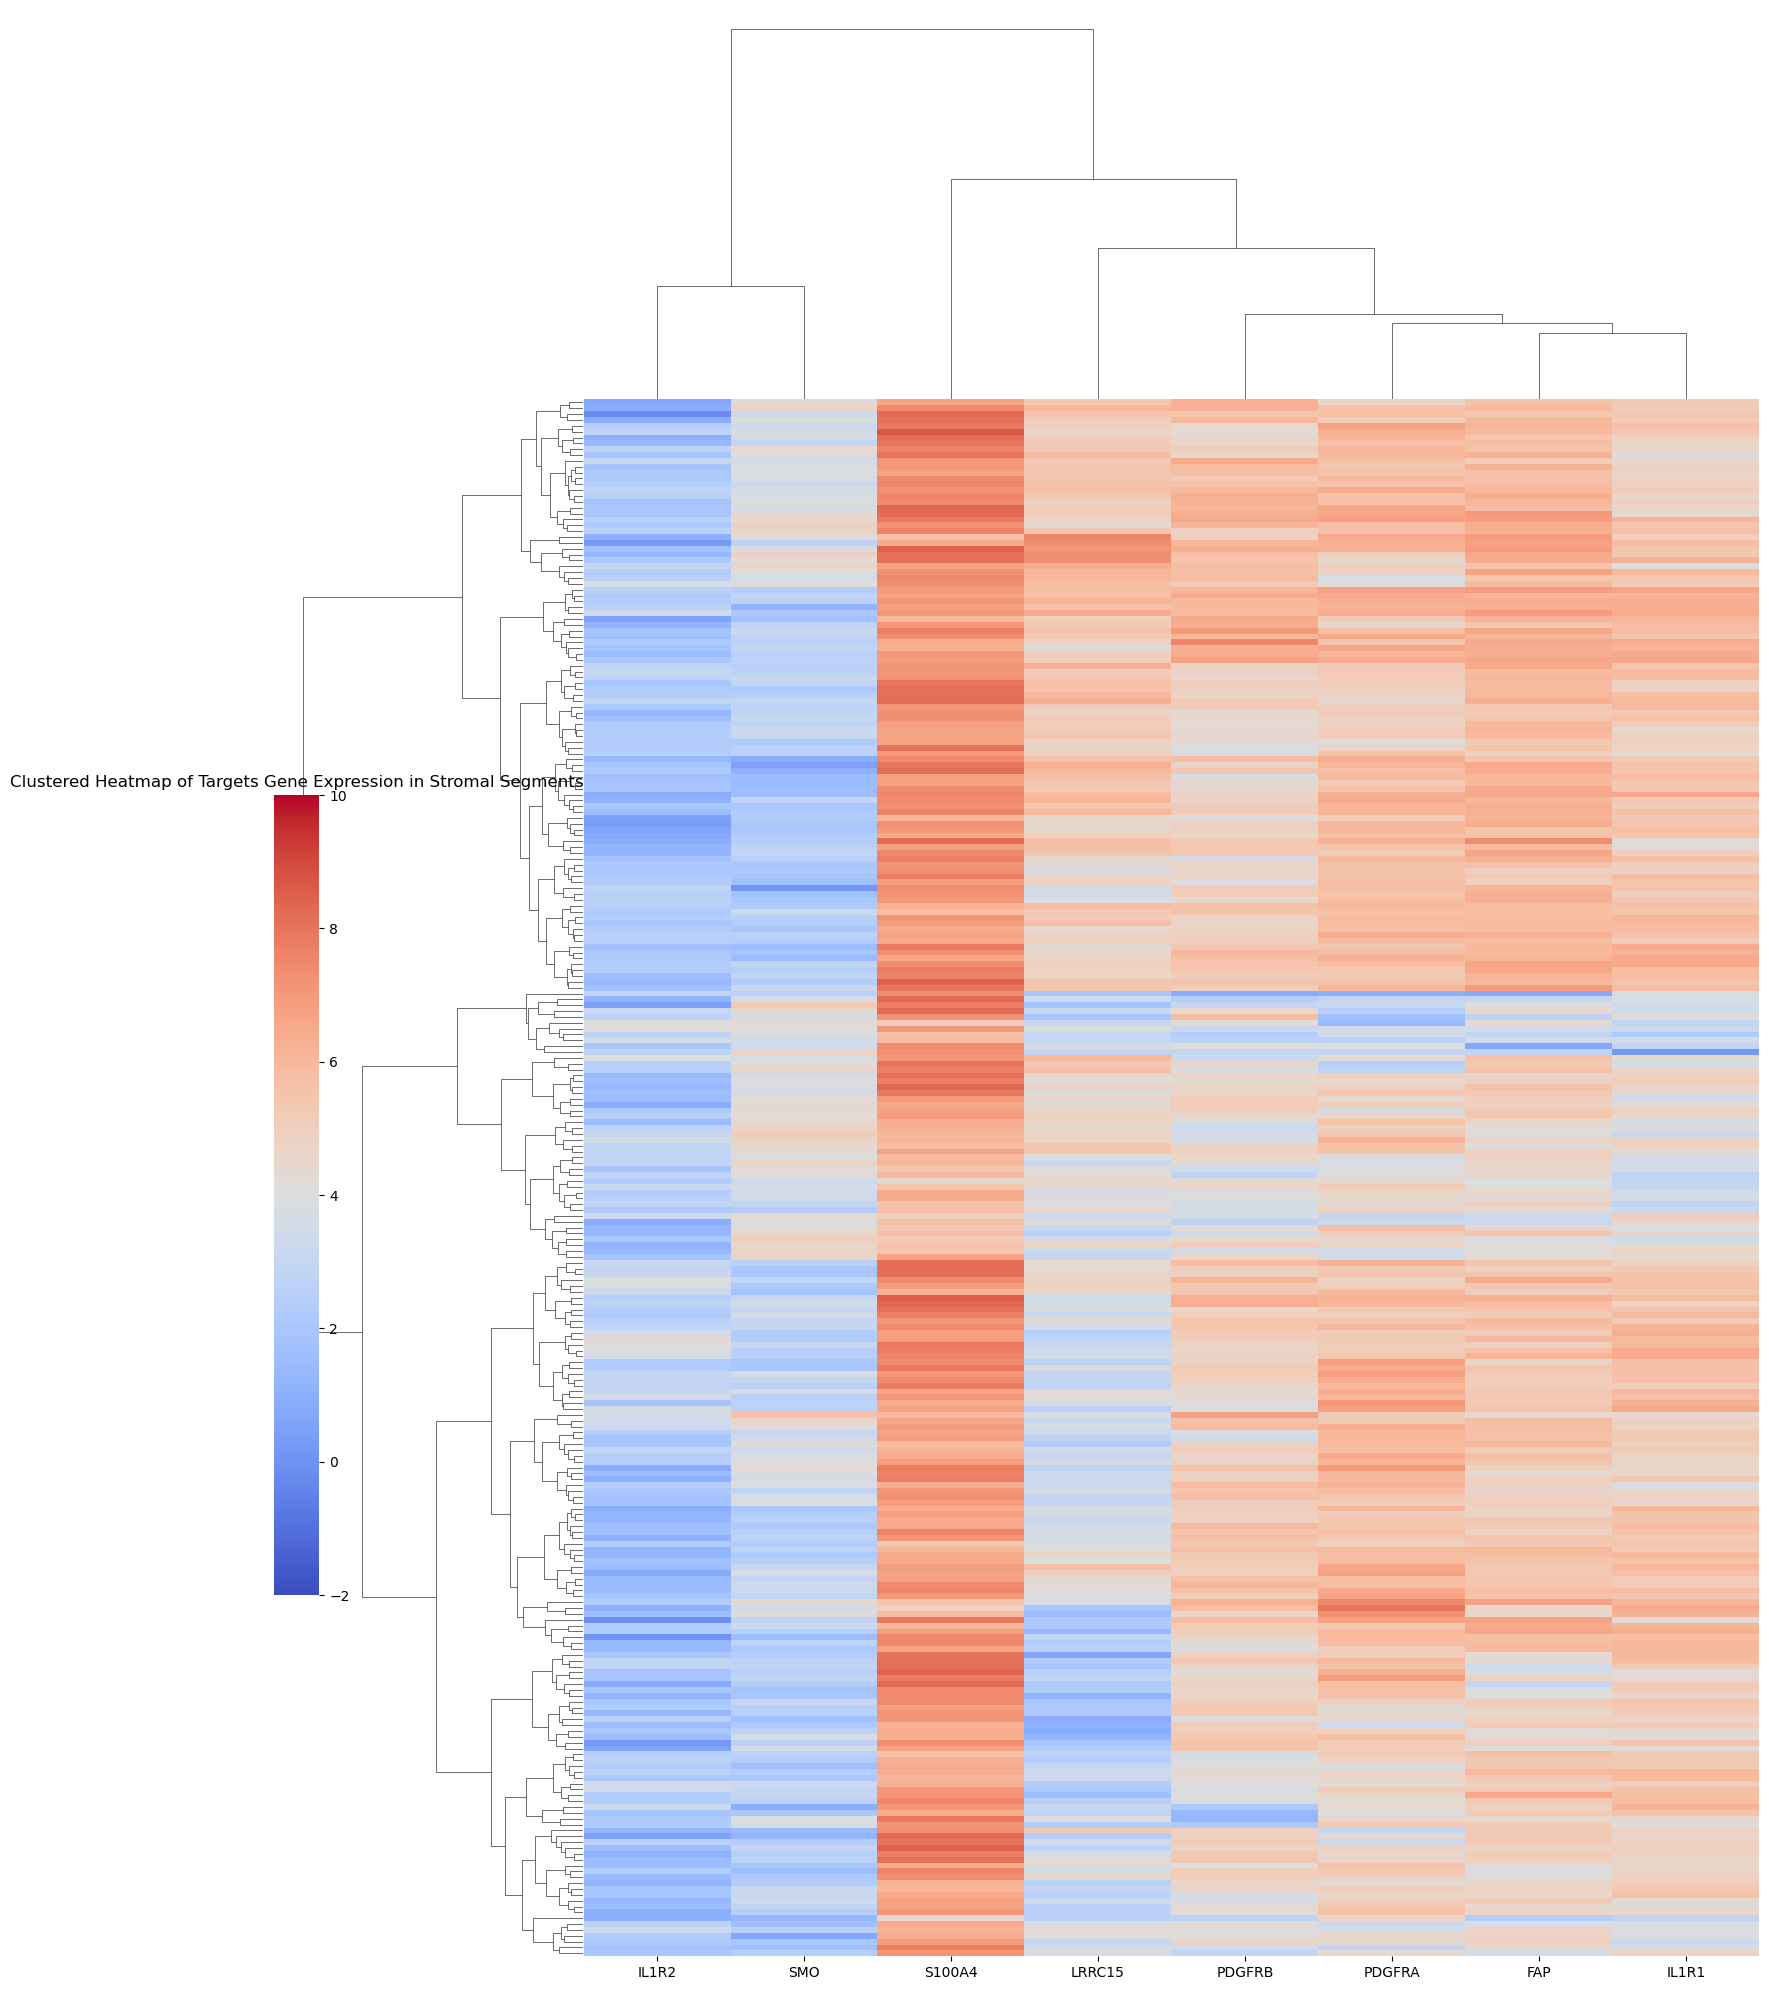

In [43]:
sns.clustermap(
    stroma_expr_matrix,  # The expression matrix (samples as rows, genes as columns)
    row_linkage=stroma_sample_linkage, 
    col_linkage=stroma_gene_linkage,  # Clustering of samples,  # Clustering of genes
    cmap='coolwarm',  # Color map for heatmap
    figsize=(15, 20),  # Size of the plot
    xticklabels=target_CAF,  # Show gene names as labels on the x-axis
    yticklabels=False,  # Show sample names as labels on the y-axis
    cbar_pos=(0, .2, .03, .4), 
    vmin=-2, # Color bar position adjustments
    vmax=10 # Set to True if you want to annotate each cell with the actual expression value
)

# Display the heatmap
plt.title("Clustered Heatmap of Targets Gene Expression in Stromal Segments")
plt.show()

In [44]:
tumor_gene_expression=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/batch_merged_geomx_harmony_corr_expr_transpose.csv")

metadata_merged=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/batch_merged_geomx_metadata.csv")
metadata_merged["dcc_filename"]= metadata_merged['dcc_filename'].str.replace('-', '.', regex=False)

tumor_gene_expression=tumor_gene_expression.merge(metadata_merged[['dcc_filename', 'Segment']], on='dcc_filename', how='left')
tumor_gene_expression


,dcc_filename,A2M,ACADM,ACADS,ACAT1,ACVRL1,PSEN1,ADA,SGCA,ADRB2,...,SLC12A6,SPATA21,SYCP2L,FGF10,IL3,IL5,MBL2,ARG1,CCL7,Segment
0,DSP.1001660016606.G.A02.dcc,6.804666,3.813770,3.094522,3.164409,3.379704,4.040574,2.899794,3.971268,1.660338,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stroma
1,DSP.1001660016606.G.A03.dcc,6.260479,4.098920,2.754026,3.695262,3.204526,4.713780,2.037078,3.807079,1.459433,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tumor
2,DSP.1001660016606.G.A04.dcc,6.558231,3.995816,3.354820,3.765523,2.918882,3.908741,3.160093,3.933863,2.369323,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stroma
3,DSP.1001660016606.G.A05.dcc,6.372312,3.182476,2.866057,3.848748,1.562825,4.439850,2.001105,4.093993,1.666247,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tumor
4,DSP.1001660016606.G.A06.dcc,7.417367,3.226799,2.810282,4.366523,3.352077,3.631273,2.465758,3.329628,1.619624,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stroma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,DSP.1001660037247.C.D02.dcc,8.166184,5.241664,3.124489,3.526732,3.990766,4.529707,2.097933,3.164388,2.191627,...,2.486022,1.303624,4.220623,3.404106,1.639313,0.528117,1.784708,1.268932,1.171722,stroma
500,DSP.1001660037247.C.D03.dcc,6.376363,5.552360,2.214444,5.236922,3.291828,5.162804,1.452677,2.908834,0.359455,...,1.448833,1.971167,2.171534,1.837595,0.993433,2.067794,3.294537,0.338434,0.994699,tumor
501,DSP.1001660037247.C.D04.dcc,5.965432,4.531758,3.336801,4.182140,4.394296,2.165280,3.052810,0.851340,2.393427,...,2.696280,1.463408,2.607464,3.337978,2.273930,4.099109,1.475635,1.923790,1.826580,stroma
502,DSP.1001660037247.C.D05.dcc,4.274683,4.829125,4.450223,5.702187,2.662740,5.174575,2.488751,3.088751,0.339813,...,2.484907,2.905090,1.682048,2.462543,2.462948,0.763774,0.365711,2.561423,0.535245,tumor


In [ ]:
# Filter for "tumor" segment
tumor_expr_matrix = tumor_gene_expression.loc[tumor_gene_expression["Segment"] == "tumor"]
#samples=stroma_expr_matrix["Sample"]
# Select the target genes related to CAF (target_CAF)
tumor_expr_matrix = tumor_expr_matrix.loc[:, target_CAF]

# Ensure all values are floats (if they're not already)
tumor_expr_matrix = tumor_expr_matrix.values
tumor_expr_matrix = np.array(tumor_expr_matrix)
tumor_expr_matrix = tumor_expr_matrix.astype(float)

# Compute the distance matrix for genes and samples
tumor_sample_dist = sch.distance.pdist(tumor_expr_matrix, metric='euclidean')
tumor_gene_dist = sch.distance.pdist(tumor_expr_matrix.T, metric='euclidean')

# Perform hierarchical clustering (using complete linkage)
tumor_sample_linkage = sch.linkage(tumor_sample_dist, method='ward')
tumor_gene_linkage = sch.linkage(tumor_gene_dist, method='ward')

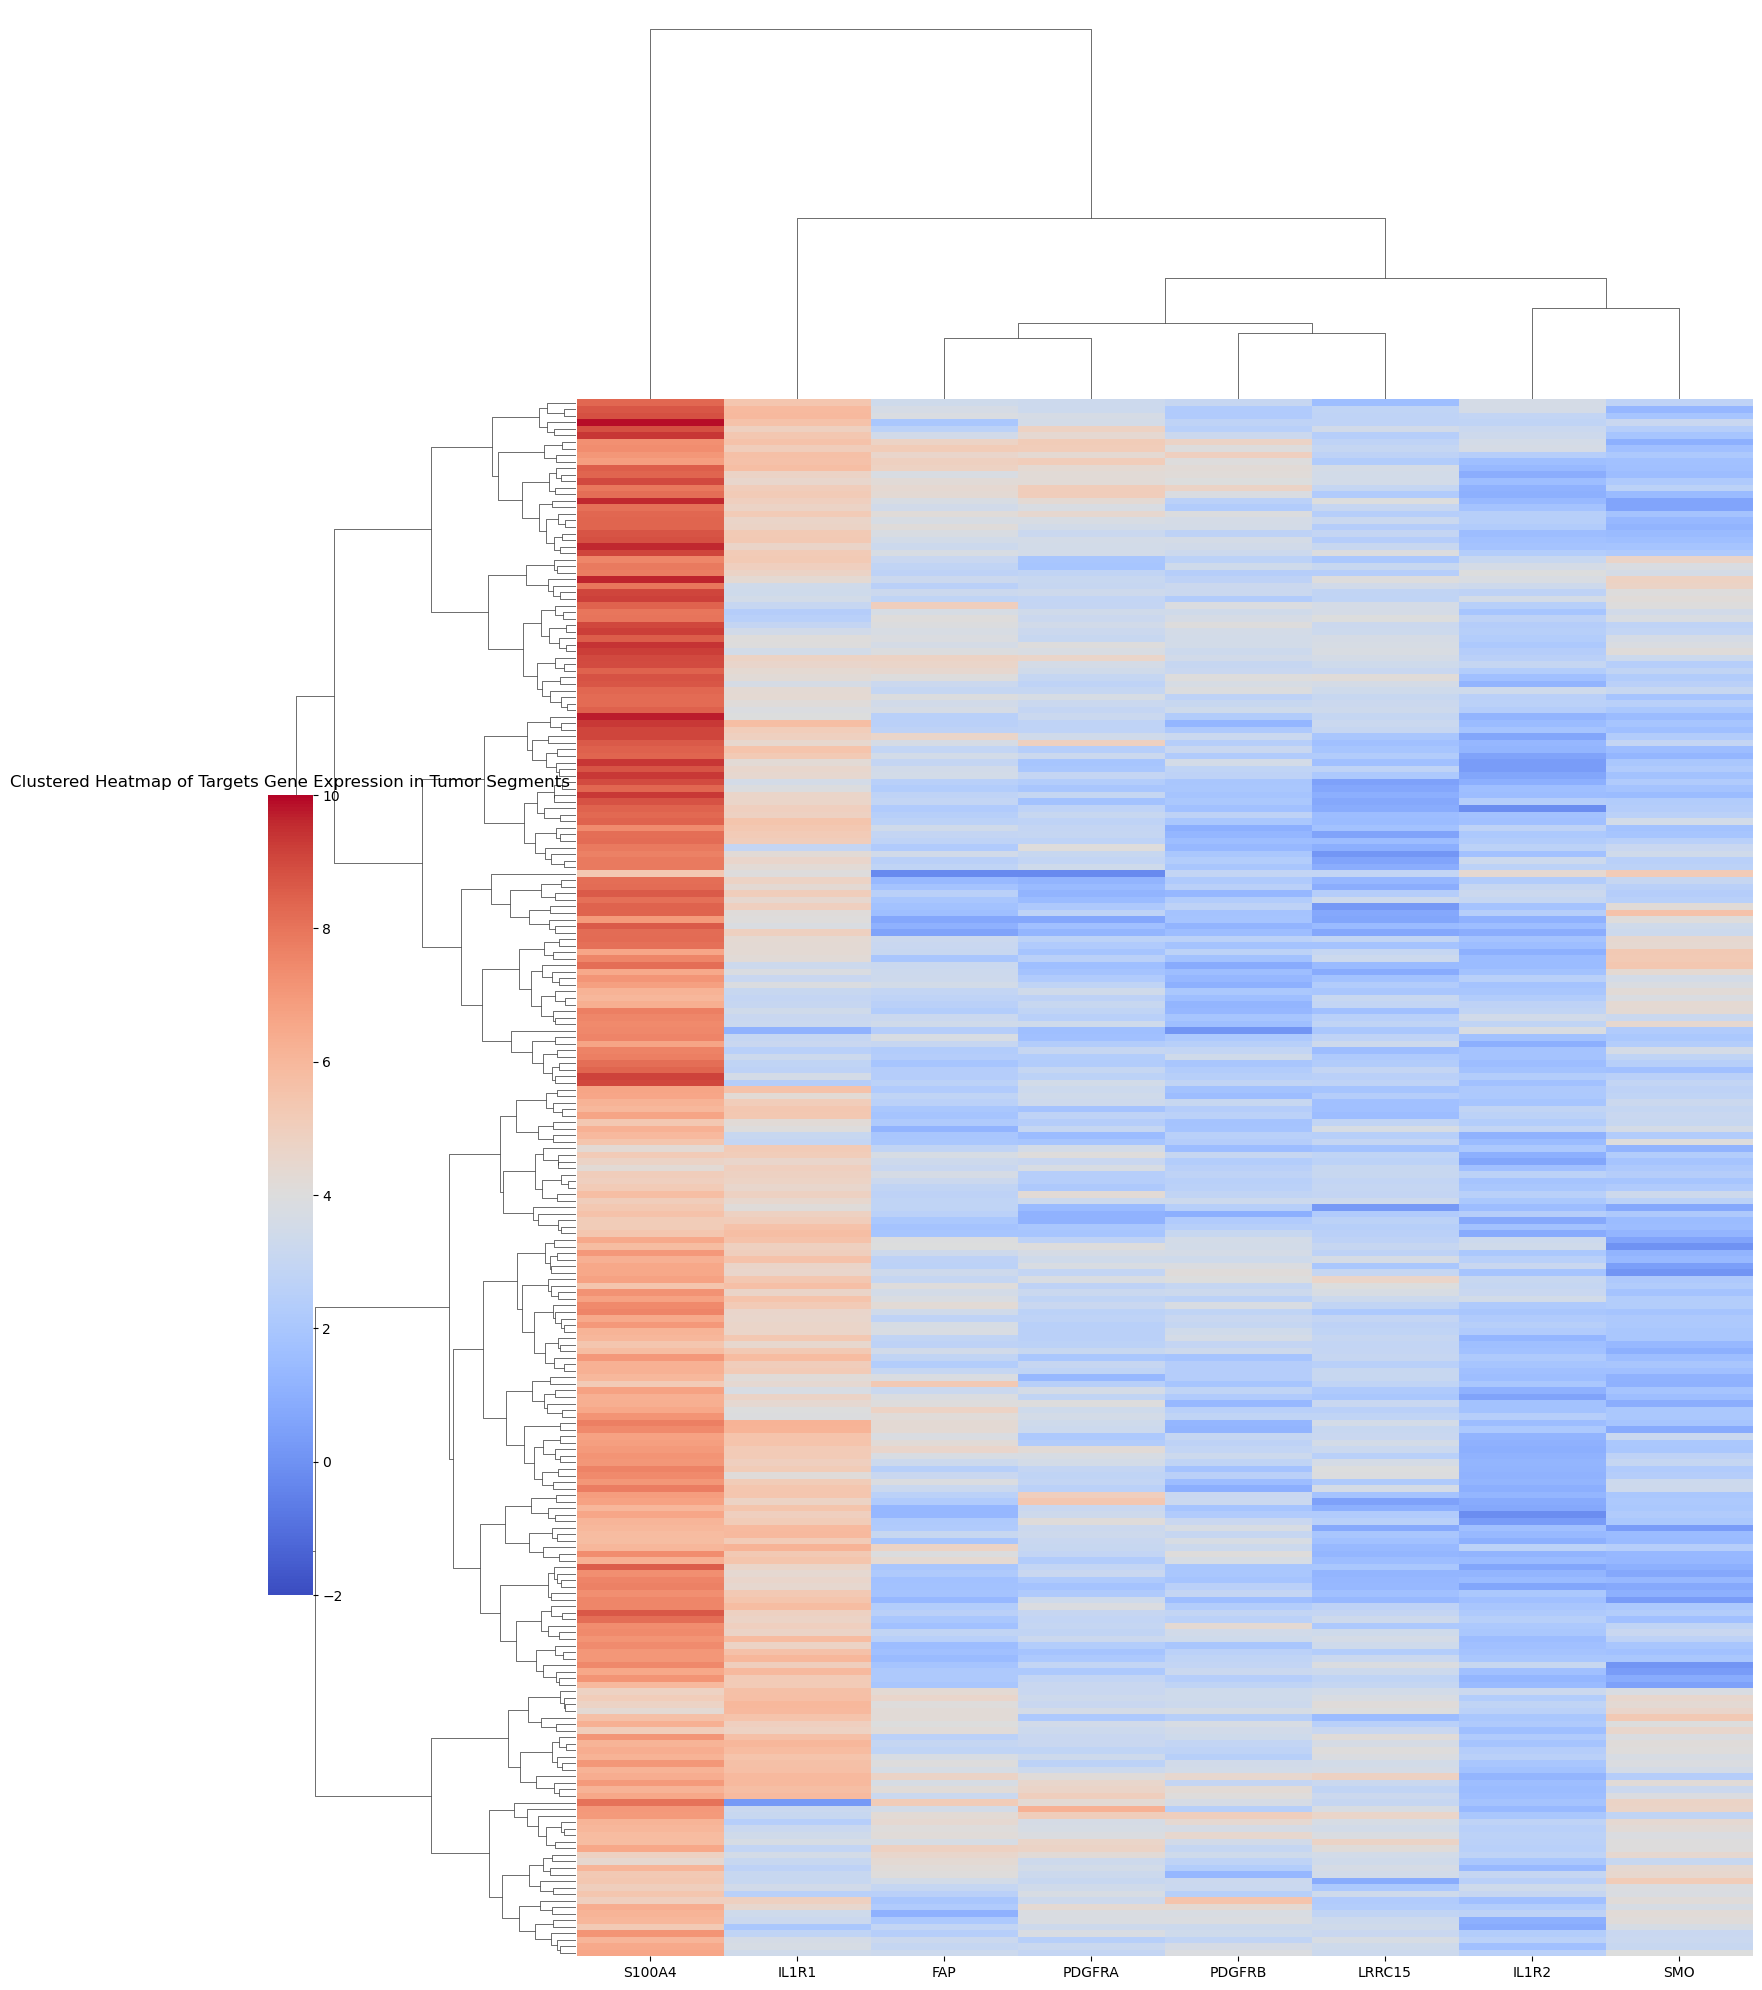

In [ ]:
sns.clustermap(
    tumor_expr_matrix,  # The expression matrix (samples as rows, genes as columns)
    row_linkage=tumor_sample_linkage, 
    col_linkage=tumor_gene_linkage,  # Clustering of samples,  # Clustering of genes
    cmap='coolwarm',  # Color map for heatmap
    figsize=(15, 20),  # Size of the plot
    xticklabels=target_CAF,  # Show gene names as labels on the x-axis
    yticklabels=False,  # Show sample names as labels on the y-axis
    cbar_pos=(0, .2, .03, .4), 
    vmin=-2, # Color bar position adjustments
    vmax=10 # Set to True if you want to annotate each cell with the actual expression value
)

# Display the heatmap
plt.title("Clustered Heatmap of Targets Gene Expression in Tumor Segments")
plt.show()

In [ ]:
"""
# Filter for "tumor" segment
stroma_expr_matrix = stromal_gene_expression.loc[stromal_gene_expression["Segment"] == "stroma"]
#samples=stroma_expr_matrix["Sample"]
# Select the target genes related to CAF (target_CAF)
stroma_expr_matrix = stroma_expr_matrix.loc[:, cafs_factors_receptors]

# Ensure all values are floats (if they're not already)
stroma_expr_matrix = stroma_expr_matrix.values
stroma_expr_matrix = np.array(stroma_expr_matrix)
stroma_expr_matrix = stroma_expr_matrix.astype(float)

# Compute the distance matrix for genes and samples
stroma_sample_dist = sch.distance.pdist(stroma_expr_matrix, metric='euclidean')
stroma_gene_dist = sch.distance.pdist(stroma_expr_matrix.T, metric='euclidean')

# Perform hierarchical clustering (using complete linkage)
stroma_sample_linkage = sch.linkage(stroma_sample_dist, method='ward')
stroma_gene_linkage = sch.linkage(stroma_gene_dist, method='ward')
"""

'\n# Filter for "tumor" segment\nstroma_expr_matrix = stromal_gene_expression.loc[stromal_gene_expression["Segment"] == "stroma"]\n#samples=stroma_expr_matrix["Sample"]\n# Select the target genes related to CAF (target_CAF)\nstroma_expr_matrix = stroma_expr_matrix.loc[:, cafs_factors_receptors]\n\n# Ensure all values are floats (if they\'re not already)\nstroma_expr_matrix = stroma_expr_matrix.values\nstroma_expr_matrix = np.array(stroma_expr_matrix)\nstroma_expr_matrix = stroma_expr_matrix.astype(float)\n\n# Compute the distance matrix for genes and samples\nstroma_sample_dist = sch.distance.pdist(stroma_expr_matrix, metric=\'euclidean\')\nstroma_gene_dist = sch.distance.pdist(stroma_expr_matrix.T, metric=\'euclidean\')\n\n# Perform hierarchical clustering (using complete linkage)\nstroma_sample_linkage = sch.linkage(stroma_sample_dist, method=\'ward\')\nstroma_gene_linkage = sch.linkage(stroma_gene_dist, method=\'ward\')\n'

In [ ]:
"""
sns.clustermap(
    stroma_expr_matrix,  # The expression matrix (samples as rows, genes as columns)
    row_linkage=stroma_sample_linkage, 
    col_linkage=stroma_gene_linkage,  # Clustering of samples,  # Clustering of genes
    cmap='coolwarm',  # Color map for heatmap
    figsize=(15, 20),  # Size of the plot
    xticklabels=cafs_factors_receptors,  # Show gene names as labels on the x-axis
    yticklabels=False,  # Show sample names as labels on the y-axis
    cbar_pos=(0, .2, .03, .4), 
    vmin=-2, # Color bar position adjustments
    vmax=10 # Set to True if you want to annotate each cell with the actual expression value
)

# Display the heatmap
plt.title("Clustered Heatmap of CAF derived targets in Stromal Segments")
plt.show()
"""

'\nsns.clustermap(\n    stroma_expr_matrix,  # The expression matrix (samples as rows, genes as columns)\n    row_linkage=stroma_sample_linkage, \n    col_linkage=stroma_gene_linkage,  # Clustering of samples,  # Clustering of genes\n    cmap=\'coolwarm\',  # Color map for heatmap\n    figsize=(15, 20),  # Size of the plot\n    xticklabels=cafs_factors_receptors,  # Show gene names as labels on the x-axis\n    yticklabels=False,  # Show sample names as labels on the y-axis\n    cbar_pos=(0, .2, .03, .4), \n    vmin=-2, # Color bar position adjustments\n    vmax=10 # Set to True if you want to annotate each cell with the actual expression value\n)\n\n# Display the heatmap\nplt.title("Clustered Heatmap of CAF derived targets in Stromal Segments")\nplt.show()\n'

In [ ]:
tumor_gene_expression=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/batch_merged_geomx_harmony_corr_expr_transpose.csv")

metadata_merged=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/batch_merged_geomx_metadata.csv")
metadata_merged["dcc_filename"]= metadata_merged['dcc_filename'].str.replace('-', '.', regex=False)

tumor_gene_expression=tumor_gene_expression.merge(metadata_merged[['dcc_filename', 'Segment']], on='dcc_filename', how='left')
tumor_gene_expression

,dcc_filename,A2M,ACADM,ACADS,ACAT1,ACVRL1,PSEN1,ADA,SGCA,ADRB2,...,SLC12A6,SPATA21,SYCP2L,FGF10,IL3,IL5,MBL2,ARG1,CCL7,Segment
0,DSP.1001660016606.G.A02.dcc,6.804666,3.813770,3.094522,3.164409,3.379704,4.040574,2.899794,3.971268,1.660338,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stroma
1,DSP.1001660016606.G.A03.dcc,6.260479,4.098920,2.754026,3.695262,3.204526,4.713780,2.037078,3.807079,1.459433,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tumor
2,DSP.1001660016606.G.A04.dcc,6.558231,3.995816,3.354820,3.765523,2.918882,3.908741,3.160093,3.933863,2.369323,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stroma
3,DSP.1001660016606.G.A05.dcc,6.372312,3.182476,2.866057,3.848748,1.562825,4.439850,2.001105,4.093993,1.666247,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tumor
4,DSP.1001660016606.G.A06.dcc,7.417367,3.226799,2.810282,4.366523,3.352077,3.631273,2.465758,3.329628,1.619624,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stroma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,DSP.1001660037247.C.D02.dcc,8.166184,5.241664,3.124489,3.526732,3.990766,4.529707,2.097933,3.164388,2.191627,...,2.486022,1.303624,4.220623,3.404106,1.639313,0.528117,1.784708,1.268932,1.171722,stroma
500,DSP.1001660037247.C.D03.dcc,6.376363,5.552360,2.214444,5.236922,3.291828,5.162804,1.452677,2.908834,0.359455,...,1.448833,1.971167,2.171534,1.837595,0.993433,2.067794,3.294537,0.338434,0.994699,tumor
501,DSP.1001660037247.C.D04.dcc,5.965432,4.531758,3.336801,4.182140,4.394296,2.165280,3.052810,0.851340,2.393427,...,2.696280,1.463408,2.607464,3.337978,2.273930,4.099109,1.475635,1.923790,1.826580,stroma
502,DSP.1001660037247.C.D05.dcc,4.274683,4.829125,4.450223,5.702187,2.662740,5.174575,2.488751,3.088751,0.339813,...,2.484907,2.905090,1.682048,2.462543,2.462948,0.763774,0.365711,2.561423,0.535245,tumor


In [ ]:
# Filter for "tumor" segment
tumor_expr_matrix = tumor_gene_expression.loc[tumor_gene_expression["Segment"] == "tumor"]
#samples=stroma_expr_matrix["Sample"]
# Select the target genes related to CAF (target_CAF)
tumor_expr_matrix = tumor_expr_matrix.loc[:, cafs_factors_receptors]

# Ensure all values are floats (if they're not already)
tumor_expr_matrix = tumor_expr_matrix.values
tumor_expr_matrix = np.array(tumor_expr_matrix)
tumor_expr_matrix = tumor_expr_matrix.astype(float)

# Compute the distance matrix for genes and samples
tumor_sample_dist = sch.distance.pdist(tumor_expr_matrix, metric='euclidean')
tumor_gene_dist = sch.distance.pdist(tumor_expr_matrix.T, metric='euclidean')

# Perform hierarchical clustering (using complete linkage)
tumor_sample_linkage = sch.linkage(tumor_sample_dist, method='ward')
tumor_gene_linkage = sch.linkage(tumor_gene_dist, method='ward')

ValueError: The condensed distance matrix must contain only finite values.

In [ ]:
sns.clustermap(
    tumor_expr_matrix,  # The expression matrix (samples as rows, genes as columns)
    row_linkage=tumor_sample_linkage, 
    col_linkage=tumor_gene_linkage,  # Clustering of samples,  # Clustering of genes
    cmap='coolwarm',  # Color map for heatmap
    figsize=(15, 20),  # Size of the plot
    xticklabels=cafs_factors_receptors,  # Show gene names as labels on the x-axis
    yticklabels=False,  # Show sample names as labels on the y-axis
    cbar_pos=(0, .2, .03, .4), 
    vmin=-2, # Color bar position adjustments
    vmax=10 # Set to True if you want to annotate each cell with the actual expression value
)

# Display the heatmap
plt.title("Clustered Heatmap of Targets Gene Expression in Tumor Segments")
plt.show()